# `log_20260402_150754.csv` Review

This notebook reviews the latest HFE circulation log and, like the `log_20260330_161922_review` notebook, treats the file as a sequence of operating phases instead of one uniform steady-state run.

For this run the interesting structure is cleaner and more repeatable:

- **Segment 1** is a liquid-only step sweep from roughly 5% to 30% pump command.
- **Segment 2** is a warm 10% recirculation hold with very little thermal drift.
- **Segment 3** is a colder 10% hold where the fluid keeps cooling, density rises, and the thermocouple spread opens up.
- **Segment 4** is a short gas-rich tail that looks more like line emptying or void pickup than usable liquid circulation.

The main questions here are:

- how monotonic and linear the step sweep looks,
- how repeatable the two 10% holds are,
- and how tightly temperature, density, and flow move together during the long cooldown phase.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import orca
from IPython.display import display
from matplotlib.ticker import LinearLocator
from scipy.stats import linregress
import warnings

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

NB_PATH = Path.cwd()
REPO_ROOT = NB_PATH
for candidate in [NB_PATH, *NB_PATH.parents]:
    if (candidate / 'data').exists() and (candidate / 'analysis').exists():
        REPO_ROOT = candidate
        break

LOG_PATH = REPO_ROOT / 'data' / 'raw' / 'recirculation' / 'log_20260402_150754.csv'
print(f'Repo root: {REPO_ROOT}')
print(f'Log path: {LOG_PATH}')

warnings.filterwarnings(
    'ignore',
    message='FigureCanvasAgg is non-interactive, and thus cannot be shown',
    category=UserWarning,
)


Repo root: /home/aamy/Documents/hfe-system
Log path: /home/aamy/Documents/hfe-system/data/raw/recirculation/log_20260402_150754.csv


In [2]:
LB_TO_KG = 0.45359237
US_GAL_TO_M3 = 0.003785411784
FT_TO_M = 0.3048
LB_PER_GAL_TO_KG_PER_M3 = LB_TO_KG / US_GAL_TO_M3
HFE_LIQUID_DENSITY_BOUNDS = (1200.0, 1600.0)


CLASS_COLORS = {
    'gas-rich / empty': '#d62728',
    'priming / flow-direction flips': '#ff7f0e',
    'draining tail / mixed phase': '#9467bd',
    'short usable window': '#2ca02c',
    'usable liquid circulation': '#1f77b4',
}


def detect_legacy_flow_export(frame: pd.DataFrame) -> bool:
    required = {'fluid_temperature_raw', 'fluid_density_kg_m3'}
    if not required.issubset(frame.columns):
        return False

    temp_raw = frame['fluid_temperature_raw'].dropna()
    density_raw = frame['fluid_density_kg_m3'].dropna()
    if temp_raw.empty or density_raw.empty:
        return False

    return temp_raw.median() > 40.0 and density_raw.quantile(0.95) < 20.0


def add_canonical_flow_columns(frame: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    data = frame.copy()
    legacy = detect_legacy_flow_export(data)

    if legacy:
        note = (
            'This CSV looks like a legacy export: the flow-meter columns behave like '
            'ft/s, US gal/min, lb/min, degF and lb/gal even though the headers look SI. '
            'The notebook converts them to canonical SI before plotting.'
        )
        data['flow_velocity_mps_si'] = data['fluid_flow_velocity_mps'] * FT_TO_M
        data['volume_flow_m3s_si'] = data['fluid_volume_flow_m3s'] * US_GAL_TO_M3 / 60.0
        data['volume_flow_lmin_si'] = data['fluid_volume_flow_m3s'] * US_GAL_TO_M3 * 1000.0
        data['mass_flow_kgs_si'] = data['fluid_mass_flow_kgs'] * LB_TO_KG / 60.0
        data['mass_flow_kgmin_si'] = data['fluid_mass_flow_kgs'] * LB_TO_KG
        data['temperature_c_si'] = (data['fluid_temperature_raw'] - 32.0) * 5.0 / 9.0
        data['density_kg_m3_si'] = data['fluid_density_kg_m3'] * LB_PER_GAL_TO_KG_PER_M3
    else:
        note = 'This CSV already looks SI-like, so the notebook uses the logged flow-meter columns directly.'
        data['flow_velocity_mps_si'] = data.get('fluid_flow_velocity_mps', np.nan)
        data['volume_flow_m3s_si'] = data.get('fluid_volume_flow_m3s', np.nan)
        data['volume_flow_lmin_si'] = data['volume_flow_m3s_si'] * 60.0 * 1000.0
        data['mass_flow_kgs_si'] = data.get('fluid_mass_flow_kgs', np.nan)
        data['mass_flow_kgmin_si'] = data['mass_flow_kgs_si'] * 60.0
        if 'fluid_temperature_c' in data.columns:
            data['temperature_c_si'] = data['fluid_temperature_c']
        elif 'fluid_temperature_raw' in data.columns:
            data['temperature_c_si'] = data['fluid_temperature_raw'] - 273.15
        else:
            data['temperature_c_si'] = np.nan
        data['density_kg_m3_si'] = data.get('fluid_density_kg_m3', np.nan)

    data['pump_freq_hz'] = data.get('pump_freq_hz', np.nan)
    data['pump_input_power_w'] = data.get('pump_input_power_w', np.nan)
    data['pump_output_current_a'] = data.get('pump_output_current_a', np.nan)
    data['pump_output_voltage_v'] = data.get('pump_output_voltage_v', np.nan)
    data['pump_running'] = data['pump_freq_hz'].fillna(0.0) > 0.5
    lo, hi = HFE_LIQUID_DENSITY_BOUNDS
    data['liquid_like_density'] = data['density_kg_m3_si'].between(lo, hi)
    data['positive_mass_flow'] = data['mass_flow_kgmin_si'] > 0.0
    data['usable_sample'] = data['pump_running'] & data['liquid_like_density']
    data['delta_p_bar_recomputed'] = data['pump_pressure_after_bar_abs'] - data['pump_pressure_before_bar_abs']
    data['t_min'] = data['time_s'] / 60.0
    data['cmd_bucket_pct'] = data['pump_cmd_pct'].round(0)
    return data, note


def contiguous_true_segments(mask: pd.Series) -> list[tuple[int, int]]:
    values = mask.fillna(False).to_numpy()
    segments: list[tuple[int, int]] = []
    start = None
    for idx, flag in enumerate(values):
        if flag and start is None:
            start = idx
        elif not flag and start is not None:
            segments.append((start, idx - 1))
            start = None
    if start is not None:
        segments.append((start, len(values) - 1))
    return segments


def classify_segment(row: pd.Series) -> str:
    if row['liquid_fraction'] < 0.50:
        return 'gas-rich / empty'
    if row['positive_mass_flow_fraction'] < 0.75:
        return 'priming / flow-direction flips'
    if row['liquid_fraction'] < 0.90:
        return 'draining tail / mixed phase'
    if row['duration_s'] < 20.0:
        return 'short usable window'
    return 'usable liquid circulation'


def segment_slice(data: pd.DataFrame, row: pd.Series) -> pd.DataFrame:
    return data[data['time_s'].between(row['start_s'], row['end_s'])].copy()


def build_segment_summary(data: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict] = []
    for segment_id, (start, end) in enumerate(contiguous_true_segments(data['pump_running']), start=1):
        seg = data.iloc[start:end + 1].copy()
        cmd_levels = sorted({int(v) for v in seg['cmd_bucket_pct'].dropna() if abs(v) > 1e-9})
        liquid = seg[seg['liquid_like_density'] & (seg['pump_cmd_pct'] > 0.0)].copy()
        reference = liquid if not liquid.empty else seg.copy()
        row = {
            'segment_id': segment_id,
            'start_s': seg['time_s'].iloc[0],
            'end_s': seg['time_s'].iloc[-1],
            'duration_s': seg['time_s'].iloc[-1] - seg['time_s'].iloc[0],
            'cmd_level_count': len(cmd_levels),
            'pump_cmd_levels_pct': ', '.join(str(v) for v in cmd_levels) if cmd_levels else '0',
            'median_freq_hz': seg['pump_freq_hz'].median(),
            'max_freq_hz': seg['pump_freq_hz'].max(),
            'median_mass_flow_kgmin': seg['mass_flow_kgmin_si'].median(),
            'median_volume_flow_lmin': seg['volume_flow_lmin_si'].median(),
            'median_density_kg_m3': seg['density_kg_m3_si'].median(),
            'median_flow_temp_C': seg['temperature_c_si'].median(),
            'liquid_fraction': seg['liquid_like_density'].mean(),
            'positive_mass_flow_fraction': seg['positive_mass_flow'].mean(),
            'flow_temp_change_C': reference['temperature_c_si'].iloc[-1] - reference['temperature_c_si'].iloc[0],
            'density_change_kg_m3': reference['density_kg_m3_si'].iloc[-1] - reference['density_kg_m3_si'].iloc[0],
        }
        row['classification'] = classify_segment(pd.Series(row))
        rows.append(row)

    if not rows:
        return pd.DataFrame(columns=['start_s', 'end_s', 'duration_s'])

    summary = pd.DataFrame(rows).set_index('segment_id')
    summary['use_for_quantitative_flow'] = summary['classification'].eq('usable liquid circulation')
    return summary


def settled_after_start(seg: pd.DataFrame, offset_s: float) -> pd.DataFrame:
    if seg.empty:
        return seg.copy()
    elapsed = seg['time_s'] - seg['time_s'].iloc[0]
    settled = seg[elapsed >= offset_s].copy()
    return settled if not settled.empty else seg.copy()


def shade_segments(ax, summary: pd.DataFrame) -> None:
    for _, row in summary.iterrows():
        color = CLASS_COLORS.get(row['classification'], '0.85')
        ax.axvspan(row['start_s'] / 60.0, row['end_s'] / 60.0, color=color, alpha=0.12)


def command_step_summary(seg: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, float]:
    work = seg[seg['liquid_like_density'] & (seg['pump_cmd_pct'] > 0.0)].copy()
    work['cmd_bucket_pct'] = work['pump_cmd_pct'].round(0)
    work['dt_s'] = work['time_s'].diff().fillna(0.0).clip(lower=0.0)
    command_change = work['cmd_bucket_pct'].ne(work['cmd_bucket_pct'].shift(fill_value=work['cmd_bucket_pct'].iloc[0]))
    work['step_id'] = command_change.cumsum()
    work['time_from_step_s'] = work.groupby('step_id')['time_s'].transform(lambda s: s - s.iloc[0])
    settle_cutoff_s = max(work['dt_s'].median(), 2.0)
    settled = work[work['time_from_step_s'] >= settle_cutoff_s].copy()
    if settled.empty:
        settled = work.copy()

    step_windows = (
        work.groupby('step_id')
        .agg(
            cmd_pct=('cmd_bucket_pct', 'first'),
            start_s=('time_s', 'min'),
            end_s=('time_s', 'max'),
            duration_s=('time_s', lambda s: s.iloc[-1] - s.iloc[0]),
        )
        .sort_index()
    )

    step_summary = (
        settled.groupby('cmd_bucket_pct')
        .agg(
            median_freq_hz=('pump_freq_hz', 'median'),
            median_mass_flow_kgmin=('mass_flow_kgmin_si', 'median'),
            median_volume_flow_lmin=('volume_flow_lmin_si', 'median'),
            median_density_kg_m3=('density_kg_m3_si', 'median'),
            median_delta_p_bar=('delta_p_bar_recomputed', 'median'),
            median_power_w=('pump_input_power_w', 'median'),
            dwell_time_s=('dt_s', 'sum'),
            sample_count=('pump_freq_hz', 'size'),
        )
        .sort_index()
    )
    step_summary['flow_per_w_kgmin_per_w'] = step_summary['median_mass_flow_kgmin'] / step_summary['median_power_w']
    return work, step_windows, step_summary, settle_cutoff_s


In [3]:
df = pd.read_csv(LOG_PATH)
df, flow_note = orca.add_canonical_flow_columns(df, log_path=LOG_PATH)
df = orca.canonicalize_tc_columns(df)
segment_summary = build_segment_summary(df)

valid_temp_cols = list(orca.connected_tc_columns(df))

quantitative_segments = segment_summary[segment_summary['use_for_quantitative_flow']].copy()
sweep_candidates = quantitative_segments[quantitative_segments['cmd_level_count'] > 1]
if sweep_candidates.empty:
    sweep_segment_id = quantitative_segments['duration_s'].idxmax()
else:
    sweep_segment_id = sweep_candidates['duration_s'].idxmax()

single_command_candidates = quantitative_segments[quantitative_segments['cmd_level_count'] == 1]
if single_command_candidates.empty:
    cooldown_segment_id = quantitative_segments['duration_s'].idxmax()
else:
    cooldown_segment_id = single_command_candidates['flow_temp_change_C'].abs().idxmax()

repeatability_segment_ids = single_command_candidates.index.to_list()

print(flow_note)
print()
print(f'Rows: {len(df):,}')
print(f'Time span: {df["time_s"].min():.1f} s to {df["time_s"].max():.1f} s')
print(f'Valid thermocouple columns: {", ".join(orca.tc_display_name(c) for c in valid_temp_cols)}')
print(f'Sweep segment: {sweep_segment_id}')
print(f'Cooldown segment: {cooldown_segment_id}')
display(segment_summary.round(3))


This CSV already looks SI-like, so the notebook uses the logged flow-meter columns directly. Legacy wrong-type TC reconstruction applied to TFO, TTI, TTO, TMI using an effective cold-junction of 21.45 °C. Per-channel room-anchor offsets were fitted from the warmest stable flow-meter segment (n=3002). April 20 room + warmup-transfer HX calibration was also applied to THM, THI.

Rows: 4,793
Time span: 191201.7 s to 199753.3 s
Valid thermocouple columns: TFO, TTI, TTO, TMI, THM, THI
Sweep segment: 1
Cooldown segment: 3


,start_s,end_s,duration_s,cmd_level_count,pump_cmd_levels_pct,median_freq_hz,max_freq_hz,median_mass_flow_kgmin,median_volume_flow_lmin,median_density_kg_m3,median_flow_temp_C,liquid_fraction,positive_mass_flow_fraction,flow_temp_change_C,density_change_kg_m3,classification,use_for_quantitative_flow
segment_id,,,,,,,,,,,,,,,,,
1,193077.656,194499.906,1422.250,5,"5, 10, 20, 25, 30",17.56,21.14,2.359,1.642,1436.167,20.269,1.000,1.000,0.382,-1.672,usable liquid circulation,True
2,195032.765,195920.281,887.516,1,10,6.72,6.76,0.924,0.644,1435.801,20.419,1.000,1.000,0.036,-0.209,usable liquid circulation,True
3,196233.937,197951.937,1718.000,1,10,6.72,6.78,0.921,0.638,1444.825,16.512,1.000,1.000,-7.833,17.455,usable liquid circulation,True
4,198891.125,198946.375,55.250,1,5,2.98,2.99,0.047,0.062,868.995,16.821,0.031,0.531,0.000,0.000,gas-rich / empty,False


In [4]:
TC_CALIBRATION_ACTIVE = False
print(
    'This pre-fix log predates the corrected thermocouple-type logging path. '
    'This file predates the corrected thermocouple-type logging path, so the applicable correction '
    'is legacy wrong-type reconstruction for Type T loop probes plus active April 20 THM/THI calibration.'
)


This pre-fix log predates the corrected thermocouple-type logging path. This file predates the corrected thermocouple-type logging path, so the applicable correction is legacy wrong-type reconstruction for Type T loop probes plus active April 20 THM/THI calibration.


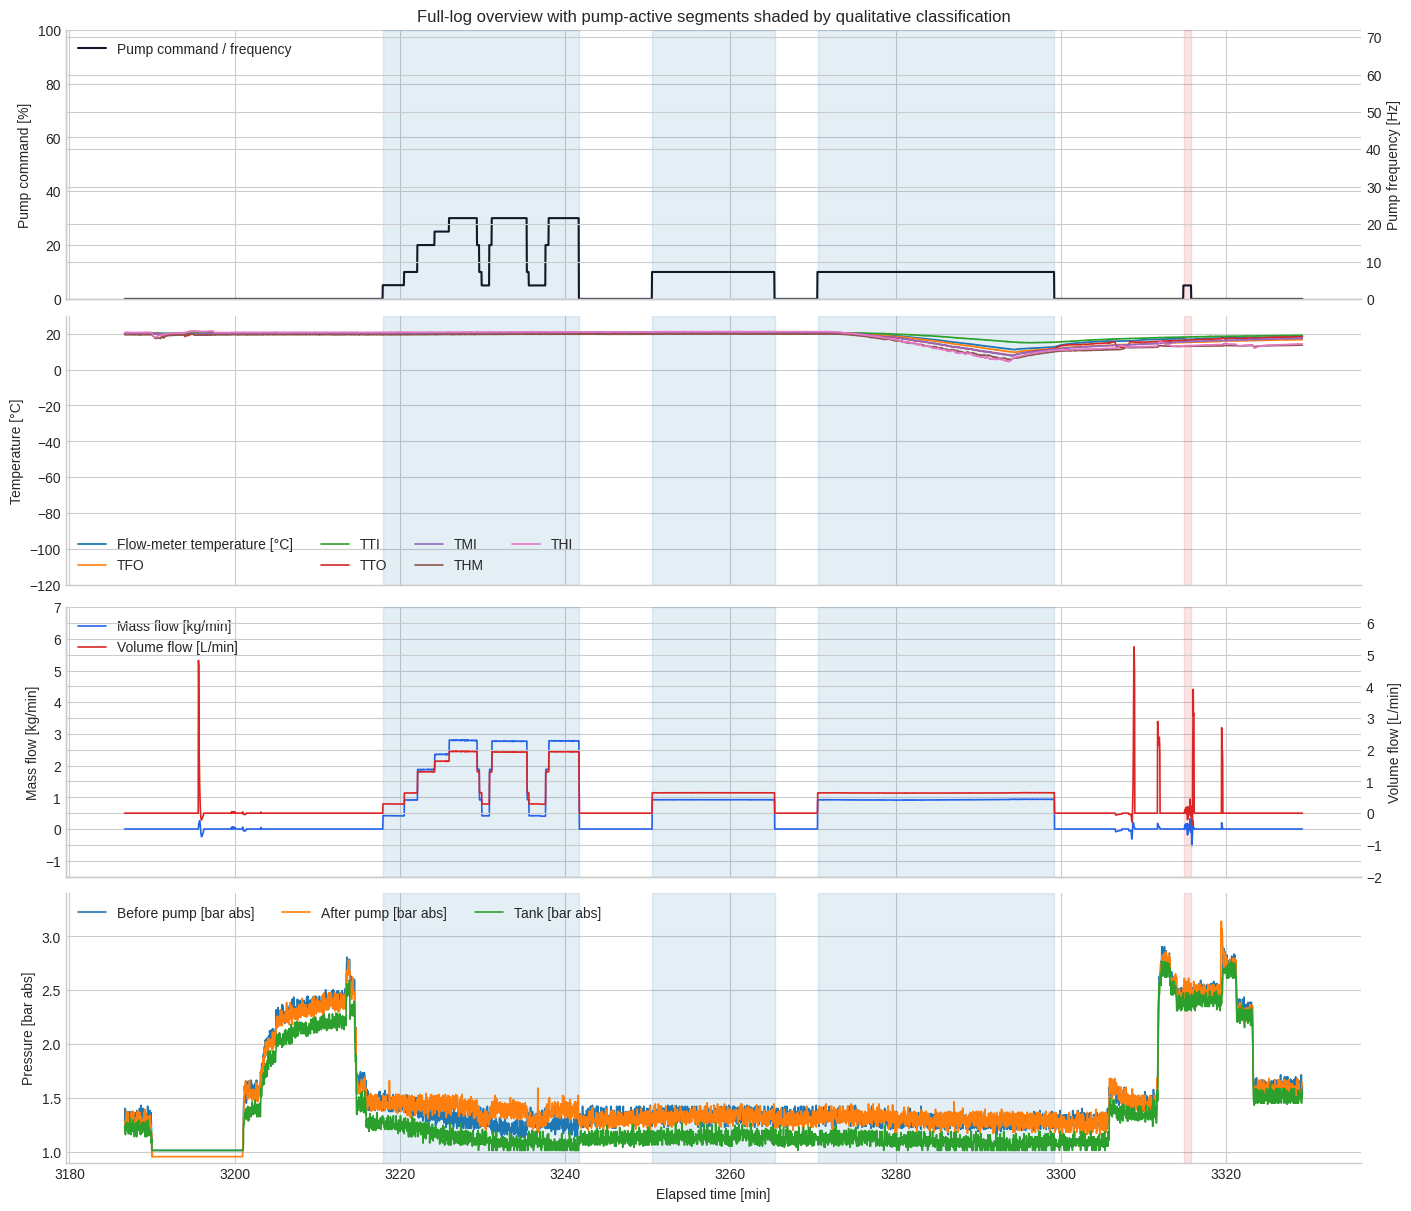

In [5]:
MAIN_OVERVIEW_PUMP_CMD_YLIM = (0.0, 100.0)
MAIN_OVERVIEW_PUMP_FREQ_YLIM = (0.0, 72.0)
MAIN_OVERVIEW_TEMPERATURE_YLIM = (-120.0, 30.0)
MAIN_OVERVIEW_MASS_FLOW_YLIM = (-1.5, 7.0)
MAIN_OVERVIEW_VOLUME_FLOW_YLIM = (-2.0, 6.5)
MAIN_OVERVIEW_PRESSURE_YLIM = (0.9, 3.4)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True, constrained_layout=True)

ax_pump_cmd = axes[0]
ax_pump_freq = ax_pump_cmd.twinx()
ax_pump_cmd.plot(df['t_min'], df['pump_cmd_pct'], label='Pump command / frequency', lw=1.5, color='#111827')
shade_segments(ax_pump_cmd, segment_summary)
ax_pump_cmd.set_ylabel('Pump command [%]')
ax_pump_cmd.set_ylim(*MAIN_OVERVIEW_PUMP_CMD_YLIM)
ax_pump_freq.set_ylabel('Pump frequency [Hz]')
ax_pump_freq.set_ylim(*MAIN_OVERVIEW_PUMP_FREQ_YLIM)
lines = ax_pump_cmd.get_lines()
ax_pump_cmd.legend(lines, [line.get_label() for line in lines], loc='best')

axes[1].plot(df['t_min'], df['temperature_c_si'], lw=1.3, label='Flow-meter temperature [°C]')
for col in valid_temp_cols:
    axes[1].plot(df['t_min'], df[col], lw=1.2, label=orca.tc_display_name(col))
axes[1].set_ylabel('Temperature [°C]')
axes[1].set_ylim(*MAIN_OVERVIEW_TEMPERATURE_YLIM)
axes[1].legend(loc='best', ncols=max(1, min(4, len(valid_temp_cols) + 1)))
shade_segments(axes[1], segment_summary)

ax_mass = axes[2]
ax_volume = ax_mass.twinx()
ax_mass.plot(df['t_min'], df['mass_flow_kgmin_si'], color='#2563eb', label='Mass flow [kg/min]', lw=1.2)
ax_volume.plot(df['t_min'], df['volume_flow_lmin_si'], color='#dc2626', label='Volume flow [L/min]', lw=1.2)
ax_mass.set_ylabel('Mass flow [kg/min]')
ax_mass.set_ylim(*MAIN_OVERVIEW_MASS_FLOW_YLIM)
ax_volume.set_ylabel('Volume flow [L/min]')
ax_volume.set_ylim(*MAIN_OVERVIEW_VOLUME_FLOW_YLIM)
shade_segments(ax_mass, segment_summary)
lines = ax_mass.get_lines() + ax_volume.get_lines()
ax_mass.legend(lines, [line.get_label() for line in lines], loc='best')

axes[3].plot(df['t_min'], df['pump_pressure_before_bar_abs'], label='Before pump [bar abs]', lw=1.2)
axes[3].plot(df['t_min'], df['pump_pressure_after_bar_abs'], label='After pump [bar abs]', lw=1.2)
axes[3].plot(df['t_min'], df['pump_pressure_tank_bar_abs'], label='Tank [bar abs]', lw=1.2)
axes[3].set_ylabel('Pressure [bar abs]')
axes[3].set_ylim(*MAIN_OVERVIEW_PRESSURE_YLIM)
axes[3].set_xlabel('Elapsed time [min]')
axes[3].legend(loc='best', ncols=3)
shade_segments(axes[3], segment_summary)

axes[0].set_title('Full-log overview with pump-active segments shaded by qualitative classification')
plt.show()

## Segment Drill-Down

The per-segment plots below make the phase split explicit. The key distinction in this log is that the long 10% windows are not equivalent: one is nearly flat, while the later one is a real cooldown transient.


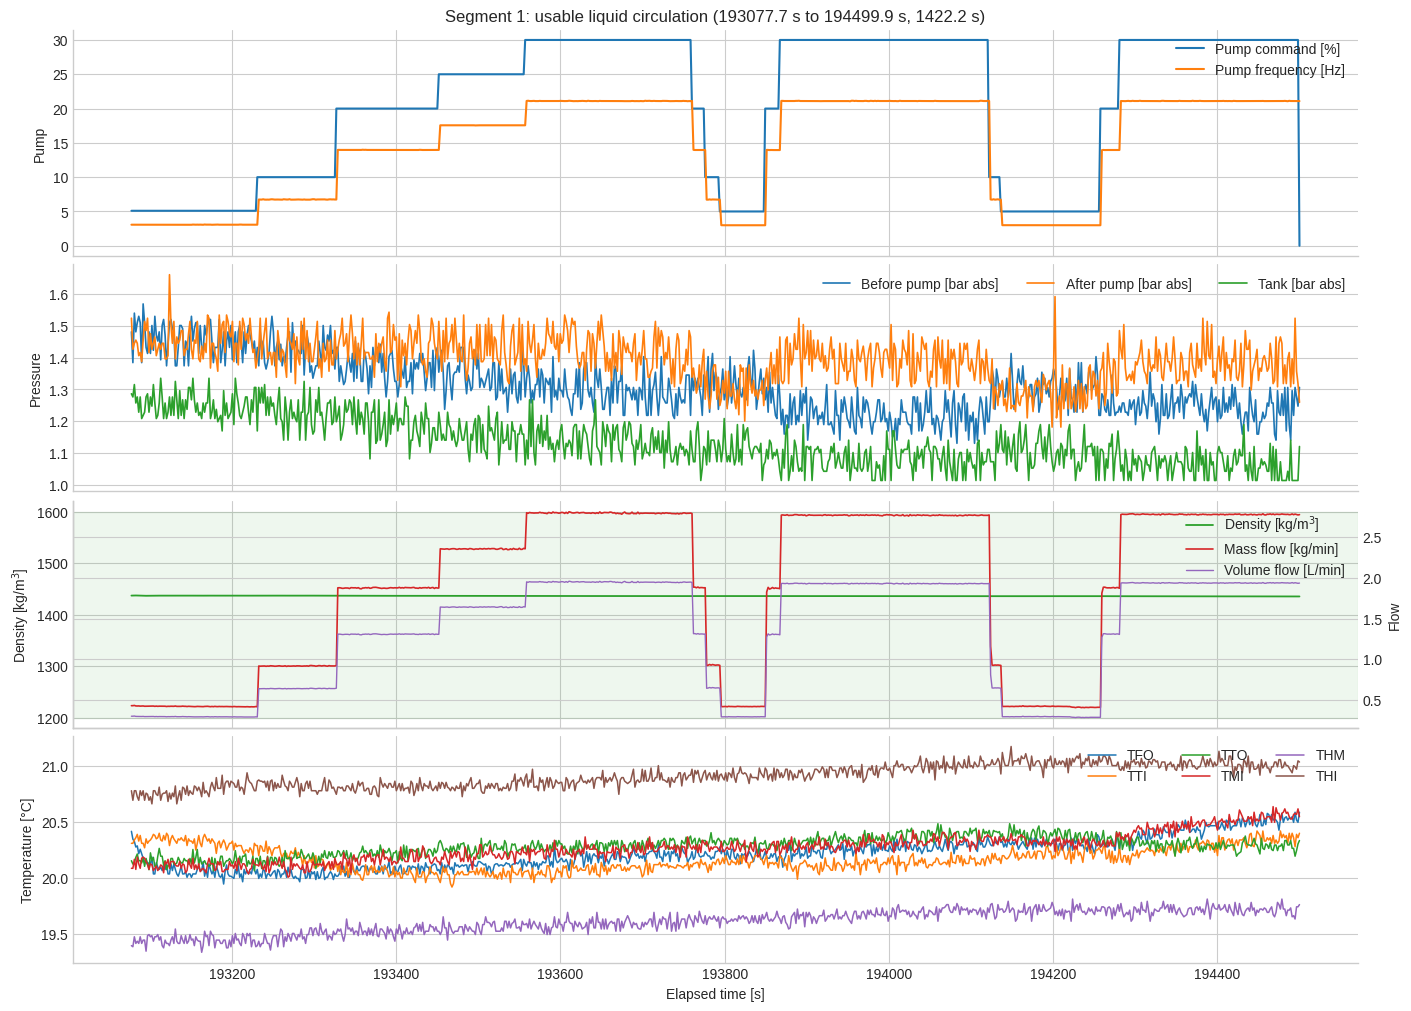

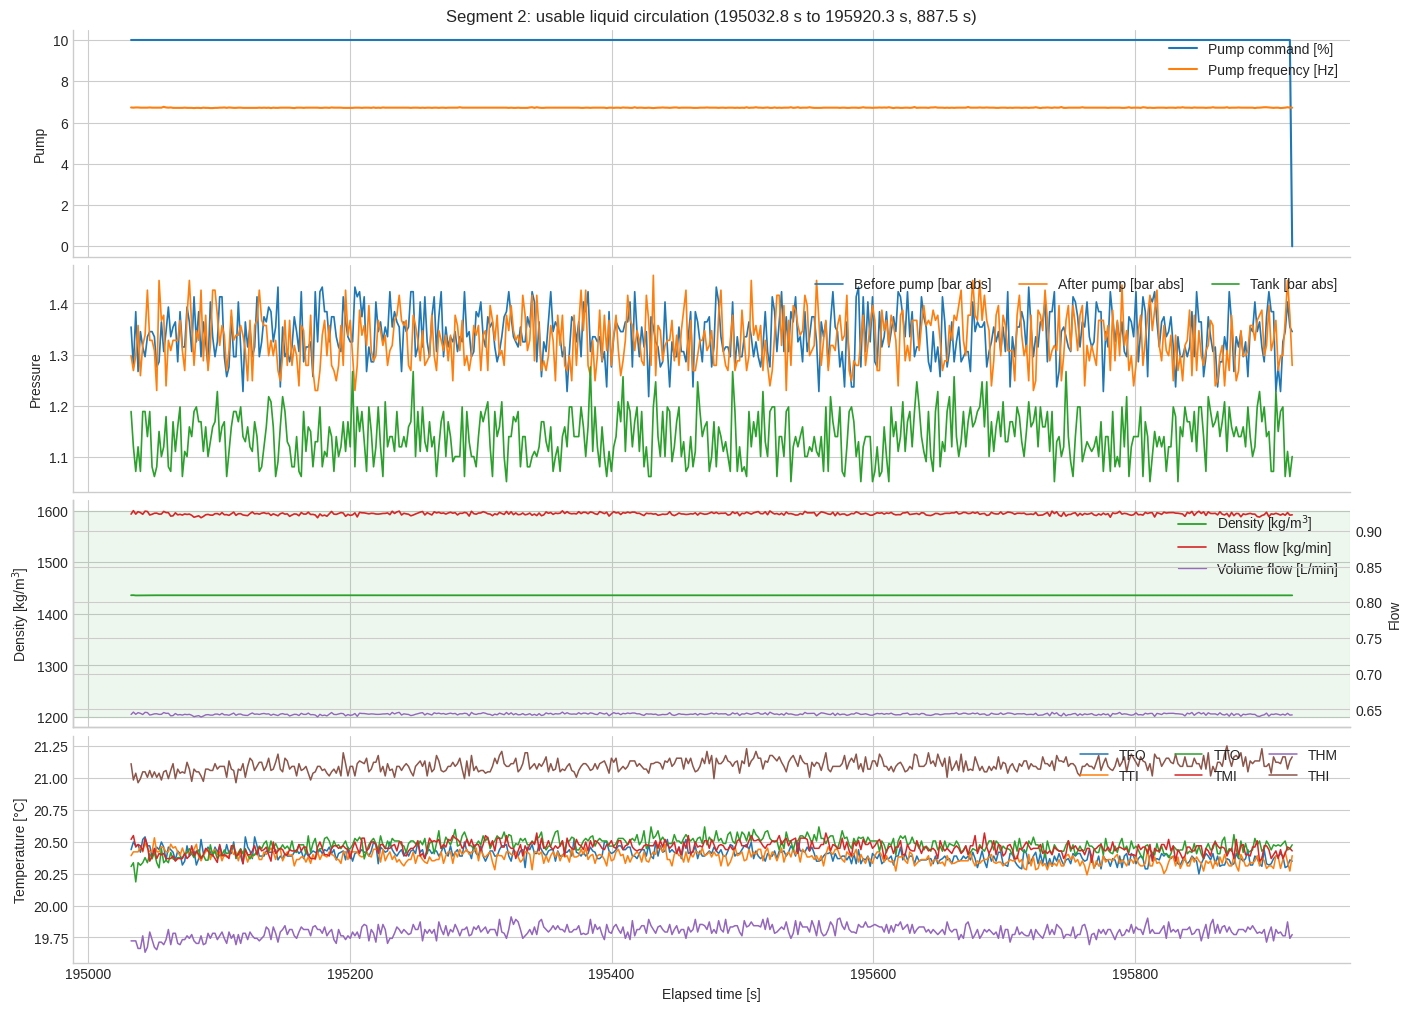

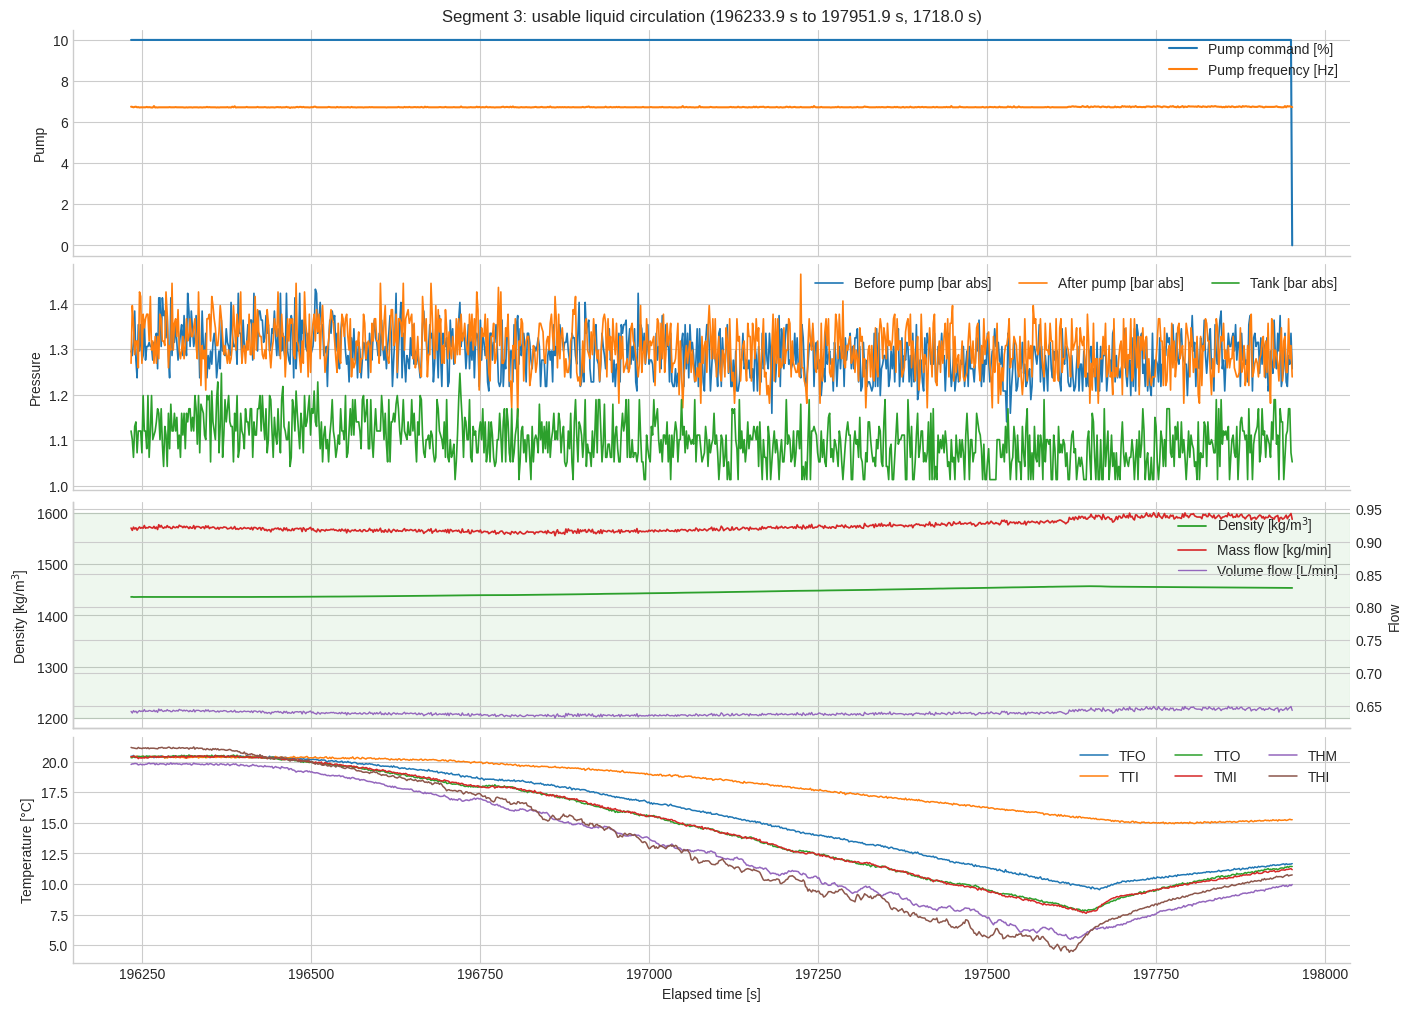

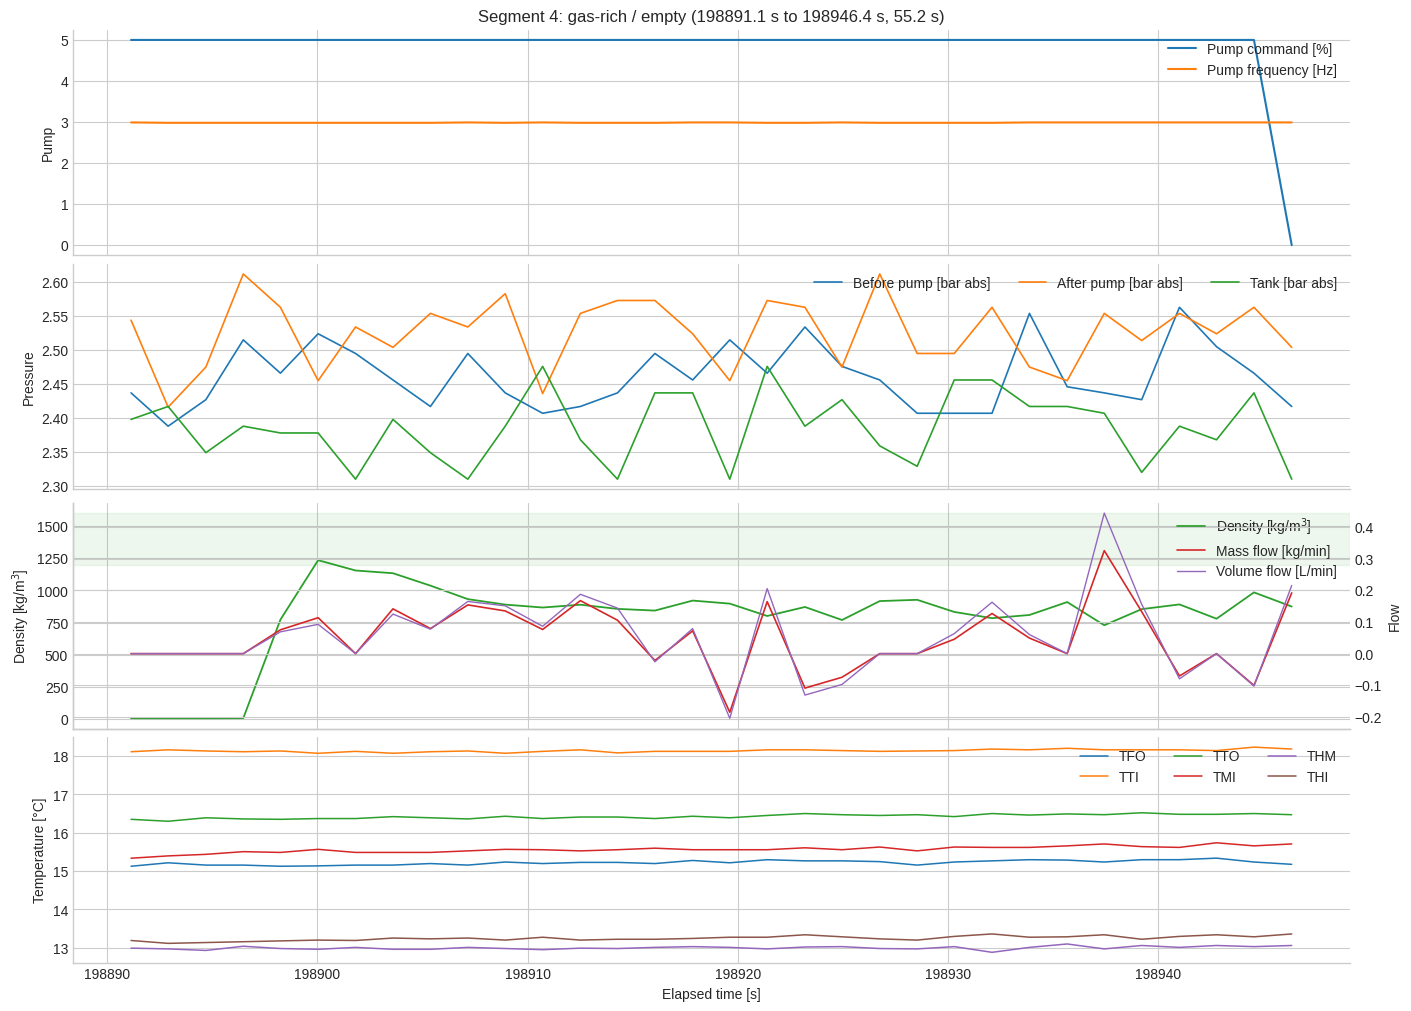

In [6]:
interesting_segments = segment_summary[segment_summary['duration_s'] >= 15.0].copy()

for segment_id, row in interesting_segments.iterrows():
    seg = segment_slice(df, row)
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

    axes[0].plot(seg['time_s'], seg['pump_cmd_pct'], label='Pump command [%]', lw=1.5)
    axes[0].plot(seg['time_s'], seg['pump_freq_hz'], label='Pump frequency [Hz]', lw=1.5)
    axes[0].legend(loc='upper right')
    axes[0].set_ylabel('Pump')
    axes[0].set_title(
        f'Segment {segment_id}: {row["classification"]} '
        f'({row["start_s"]:.1f} s to {row["end_s"]:.1f} s, {row["duration_s"]:.1f} s)'
    )

    axes[1].plot(seg['time_s'], seg['pump_pressure_before_bar_abs'], label='Before pump [bar abs]', lw=1.2)
    axes[1].plot(seg['time_s'], seg['pump_pressure_after_bar_abs'], label='After pump [bar abs]', lw=1.2)
    axes[1].plot(seg['time_s'], seg['pump_pressure_tank_bar_abs'], label='Tank [bar abs]', lw=1.2)
    axes[1].set_ylabel('Pressure')
    axes[1].legend(loc='upper right', ncols=3)

    ax_density = axes[2]
    ax_flow = ax_density.twinx()
    ax_density.plot(seg['time_s'], seg['density_kg_m3_si'], color='tab:green', lw=1.3, label='Density [kg/m$^3$]')
    ax_density.axhspan(*HFE_LIQUID_DENSITY_BOUNDS, color='tab:green', alpha=0.08)
    ax_flow.plot(seg['time_s'], seg['mass_flow_kgmin_si'], color='tab:red', lw=1.2, label='Mass flow [kg/min]')
    ax_flow.plot(seg['time_s'], seg['volume_flow_lmin_si'], color='tab:purple', lw=1.0, label='Volume flow [L/min]')
    ax_density.set_ylabel('Density [kg/m$^3$]')
    ax_flow.set_ylabel('Flow')
    lines = ax_density.get_lines() + ax_flow.get_lines()
    ax_density.legend(lines, [line.get_label() for line in lines], loc='upper right')

    for col in valid_temp_cols:
        axes[3].plot(seg['time_s'], seg[col], lw=1.1, label=orca.tc_display_name(col))
    axes[3].set_ylabel('Temperature [°C]')
    axes[3].set_xlabel('Elapsed time [s]')
    axes[3].legend(loc='upper right', ncols=3)

    plt.show()


## Repeated 10% Holds

Segments 2 and 3 are both nominally 10% recirculation, so they are a good repeatability check. Segment 2 behaves like a warm, steady operating point. Segment 3 is different: it stays at the same nominal command while the fluid cools and densifies for most of the segment.


,duration_s,flow_temp_change_C,density_change_kg_m3,median_freq_hz,median_mass_flow_kgmin,median_volume_flow_lmin,median_density_kg_m3,median_flow_temp_C,median_delta_p_bar,median_power_w,mass_flow_change_vs_seg2_pct,volume_flow_change_vs_seg2_pct
segment_id,,,,,,,,,,,,
2,887.516,0.036,-0.209,6.72,0.924,0.644,1435.794,20.421,-0.007,51.0,0.000,0.000
3,1718.000,-7.833,17.455,6.72,0.921,0.638,1446.072,15.960,0.012,51.0,-0.347,-0.895


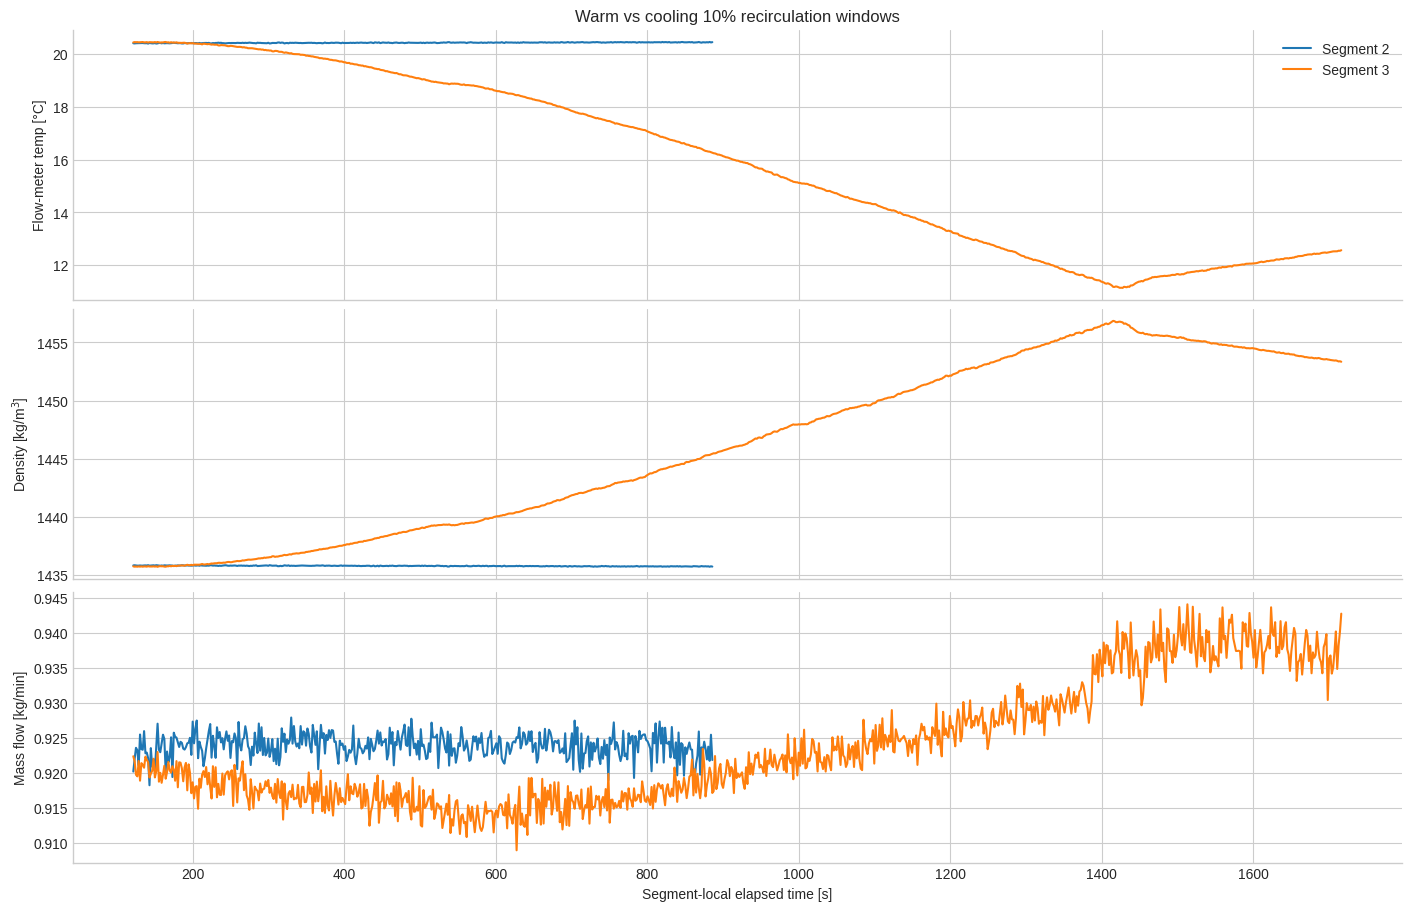

In [7]:
repeat_rows = []
repeatability_traces = {}
for segment_id in repeatability_segment_ids:
    row = segment_summary.loc[segment_id]
    seg = segment_slice(df, row)
    liquid = seg[seg['liquid_like_density'] & (seg['pump_cmd_pct'] > 0.0)].copy()
    liquid['elapsed_s'] = liquid['time_s'] - liquid['time_s'].iloc[0]
    liquid = settled_after_start(liquid, 120.0)
    repeatability_traces[segment_id] = liquid
    repeat_rows.append({
        'segment_id': segment_id,
        'duration_s': row['duration_s'],
        'flow_temp_change_C': row['flow_temp_change_C'],
        'density_change_kg_m3': row['density_change_kg_m3'],
        'median_freq_hz': liquid['pump_freq_hz'].median(),
        'median_mass_flow_kgmin': liquid['mass_flow_kgmin_si'].median(),
        'median_volume_flow_lmin': liquid['volume_flow_lmin_si'].median(),
        'median_density_kg_m3': liquid['density_kg_m3_si'].median(),
        'median_flow_temp_C': liquid['temperature_c_si'].median(),
        'median_delta_p_bar': liquid['delta_p_bar_recomputed'].median(),
        'median_power_w': liquid['pump_input_power_w'].median(),
    })

repeatability_summary = pd.DataFrame(repeat_rows).set_index('segment_id').sort_index()
repeatability_summary['mass_flow_change_vs_seg2_pct'] = 100.0 * (
    repeatability_summary['median_mass_flow_kgmin'] / repeatability_summary.iloc[0]['median_mass_flow_kgmin'] - 1.0
)
repeatability_summary['volume_flow_change_vs_seg2_pct'] = 100.0 * (
    repeatability_summary['median_volume_flow_lmin'] / repeatability_summary.iloc[0]['median_volume_flow_lmin'] - 1.0
)
display(repeatability_summary.round(3))

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, constrained_layout=True)
for segment_id, seg in repeatability_traces.items():
    axes[0].plot(seg['elapsed_s'], seg['temperature_c_si'], lw=1.5, label=f'Segment {segment_id}')
    axes[1].plot(seg['elapsed_s'], seg['density_kg_m3_si'], lw=1.5, label=f'Segment {segment_id}')
    axes[2].plot(seg['elapsed_s'], seg['mass_flow_kgmin_si'], lw=1.5, label=f'Segment {segment_id}')

axes[0].set_ylabel('Flow-meter temp [°C]')
axes[1].set_ylabel('Density [kg/m$^3$]')
axes[2].set_ylabel('Mass flow [kg/min]')
axes[2].set_xlabel('Segment-local elapsed time [s]')
axes[0].legend(loc='upper right')
axes[0].set_title('Warm vs cooling 10% recirculation windows')
plt.show()


## Segment 1: Multi-Command Sweep

The first long liquid segment is the most useful place to inspect pump-command monotonicity, approximate linearity, and any power or pressure trends that appear as the command is stepped up.


Segment 1 step-settling cutoff: 2.00 s
Mass flow vs frequency slope: 0.1314 kg/min/Hz, r^2 = 0.9997
Volume flow vs frequency slope: 0.0915 L/min/Hz, r^2 = 0.9997
Input power vs frequency slope: 1.4526 W/Hz, r^2 = 0.9256


,median_freq_hz,median_mass_flow_kgmin,median_volume_flow_lmin,median_density_kg_m3,median_delta_p_bar,median_power_w,dwell_time_s,sample_count,flow_per_w_kgmin_per_w
cmd_bucket_pct,,,,,,,,,
5.0,3.00,0.417,0.290,1436.176,-0.008,38.0,319.031,179,0.011
10.0,6.74,0.916,0.638,1436.959,-0.011,51.0,117.640,66,0.018
20.0,13.96,1.878,1.307,1436.631,0.071,60.0,167.515,94,0.031
25.0,17.56,2.357,1.641,1436.477,0.090,63.0,101.578,57,0.037
30.0,21.10,2.781,1.937,1436.051,0.149,66.0,666.531,374,0.042


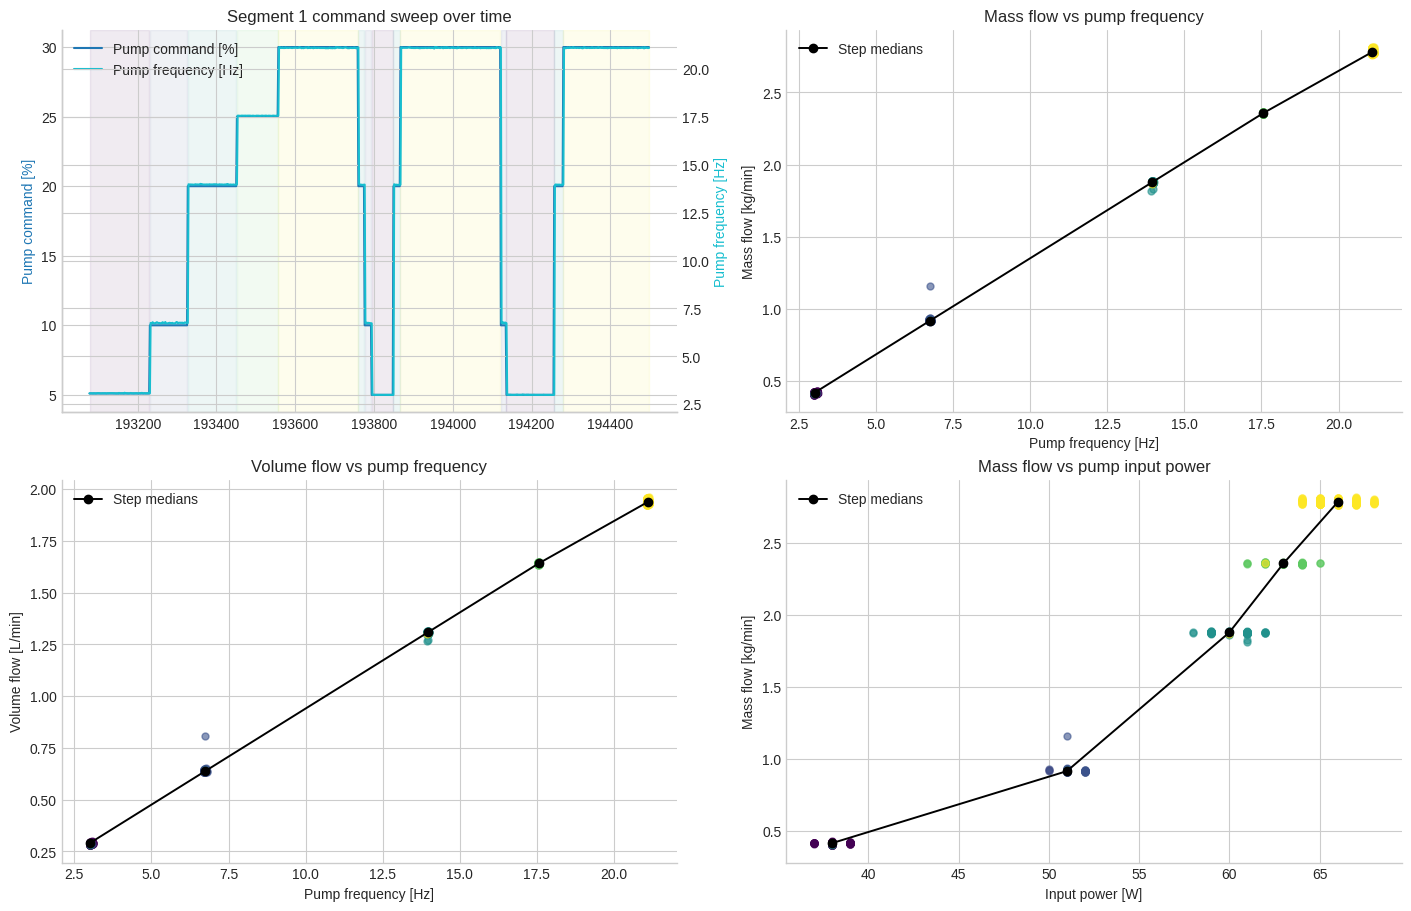

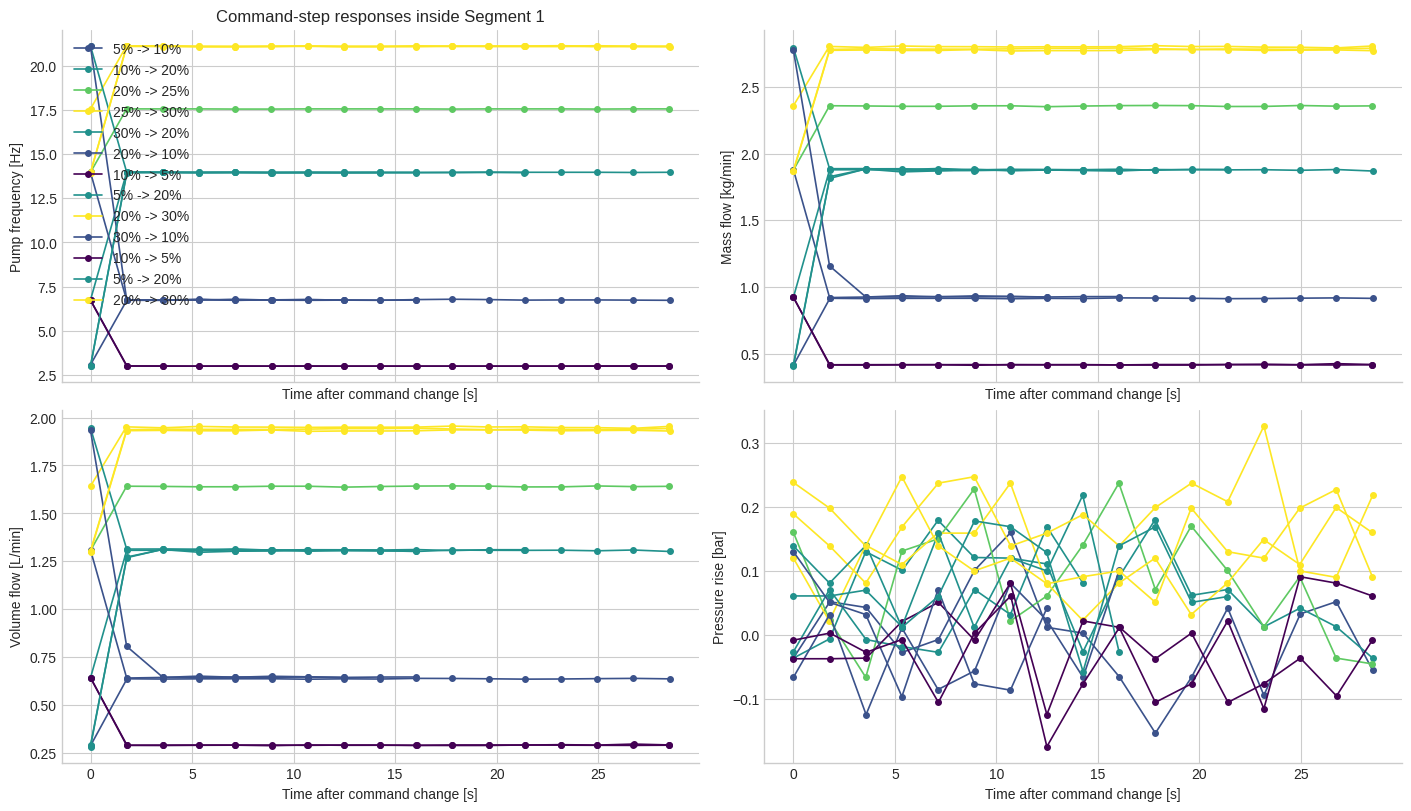

In [8]:
sweep_row = segment_summary.loc[sweep_segment_id]
sweep = segment_slice(df, sweep_row)
sweep_liquid, sweep_windows, sweep_step_summary, settle_cutoff_s = command_step_summary(sweep)

fit_mass = linregress(sweep_step_summary['median_freq_hz'], sweep_step_summary['median_mass_flow_kgmin'])
fit_volume = linregress(sweep_step_summary['median_freq_hz'], sweep_step_summary['median_volume_flow_lmin'])
fit_power = linregress(sweep_step_summary['median_freq_hz'], sweep_step_summary['median_power_w'])

print(f'Segment {sweep_segment_id} step-settling cutoff: {settle_cutoff_s:.2f} s')
print(f'Mass flow vs frequency slope: {fit_mass.slope:.4f} kg/min/Hz, r^2 = {fit_mass.rvalue**2:.4f}')
print(f'Volume flow vs frequency slope: {fit_volume.slope:.4f} L/min/Hz, r^2 = {fit_volume.rvalue**2:.4f}')
print(f'Input power vs frequency slope: {fit_power.slope:.4f} W/Hz, r^2 = {fit_power.rvalue**2:.4f}')
display(sweep_step_summary.round(3))

command_colors = {
    cmd: plt.cm.viridis(idx / max(len(sweep_step_summary.index) - 1, 1))
    for idx, cmd in enumerate(sweep_step_summary.index)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

for _, step in sweep_windows.iterrows():
    color = command_colors[step['cmd_pct']]
    axes[0, 0].axvspan(step['start_s'], step['end_s'], color=color, alpha=0.08, zorder=0)
axes[0, 0].plot(sweep_liquid['time_s'], sweep_liquid['pump_cmd_pct'], lw=1.5, color='tab:blue', label='Pump command [%]')
ax_freq = axes[0, 0].twinx()
ax_freq.plot(sweep_liquid['time_s'], sweep_liquid['pump_freq_hz'], lw=1.5, color='tab:cyan', label='Pump frequency [Hz]')
axes[0, 0].set_ylabel('Pump command [%]', color='tab:blue')
ax_freq.set_ylabel('Pump frequency [Hz]', color='tab:cyan')
axes[0, 0].set_title('Segment 1 command sweep over time')
lines = axes[0, 0].get_lines() + ax_freq.get_lines()
axes[0, 0].legend(lines, [line.get_label() for line in lines], loc='upper left')

for cmd in sweep_step_summary.index:
    subset = sweep_liquid[sweep_liquid['cmd_bucket_pct'] == cmd]
    axes[0, 1].scatter(subset['pump_freq_hz'], subset['mass_flow_kgmin_si'], s=25, alpha=0.6, color=command_colors[cmd])
axes[0, 1].plot(
    sweep_step_summary['median_freq_hz'],
    sweep_step_summary['median_mass_flow_kgmin'],
    color='black', marker='o', lw=1.4, label='Step medians'
)
axes[0, 1].set_xlabel('Pump frequency [Hz]')
axes[0, 1].set_ylabel('Mass flow [kg/min]')
axes[0, 1].set_title('Mass flow vs pump frequency')
axes[0, 1].legend(loc='upper left')

for cmd in sweep_step_summary.index:
    subset = sweep_liquid[sweep_liquid['cmd_bucket_pct'] == cmd]
    axes[1, 0].scatter(subset['pump_freq_hz'], subset['volume_flow_lmin_si'], s=25, alpha=0.6, color=command_colors[cmd])
axes[1, 0].plot(
    sweep_step_summary['median_freq_hz'],
    sweep_step_summary['median_volume_flow_lmin'],
    color='black', marker='o', lw=1.4, label='Step medians'
)
axes[1, 0].set_xlabel('Pump frequency [Hz]')
axes[1, 0].set_ylabel('Volume flow [L/min]')
axes[1, 0].set_title('Volume flow vs pump frequency')
axes[1, 0].legend(loc='upper left')

for cmd in sweep_step_summary.index:
    subset = sweep_liquid[sweep_liquid['cmd_bucket_pct'] == cmd]
    axes[1, 1].scatter(subset['pump_input_power_w'], subset['mass_flow_kgmin_si'], s=25, alpha=0.6, color=command_colors[cmd])
axes[1, 1].plot(
    sweep_step_summary['median_power_w'],
    sweep_step_summary['median_mass_flow_kgmin'],
    color='black', marker='o', lw=1.4, label='Step medians'
)
axes[1, 1].set_xlabel('Input power [W]')
axes[1, 1].set_ylabel('Mass flow [kg/min]')
axes[1, 1].set_title('Mass flow vs pump input power')
axes[1, 1].legend(loc='upper left')

plt.show()

response_window_s = 30.0
transition_ids = sweep_windows.index[sweep_windows.index > sweep_windows.index.min()]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True, sharex=True)
response_specs = [
    ((0, 0), 'pump_freq_hz', 'Pump frequency [Hz]'),
    ((0, 1), 'mass_flow_kgmin_si', 'Mass flow [kg/min]'),
    ((1, 0), 'volume_flow_lmin_si', 'Volume flow [L/min]'),
    ((1, 1), 'delta_p_bar_recomputed', 'Pressure rise [bar]'),
]
for step_id in transition_ids:
    subset = sweep_liquid[(sweep_liquid['step_id'] == step_id) & (sweep_liquid['time_from_step_s'] <= response_window_s)]
    prev_cmd = sweep_windows.loc[step_id - 1, 'cmd_pct']
    cmd = sweep_windows.loc[step_id, 'cmd_pct']
    label = f'{int(prev_cmd)}% -> {int(cmd)}%'
    color = command_colors[cmd]
    for (row_idx, col_idx), value_col, ylabel in response_specs:
        axes[row_idx, col_idx].plot(subset['time_from_step_s'], subset[value_col], marker='o', ms=4, lw=1.2, color=color, label=label)
        axes[row_idx, col_idx].set_ylabel(ylabel)

for ax in axes.flat:
    ax.set_xlabel('Time after command change [s]')
axes[0, 0].legend(loc='upper left')
axes[0, 0].set_title('Command-step responses inside Segment 1')
plt.show()


## Segment 3: Cooldown Hold

The most interesting part of this file is the long single-command cooldown hold. The nominal pump setting is almost fixed, but the thermal state is not: the flow-meter temperature falls steadily, density rises almost linearly against temperature, and the thermal spread across the thermocouples widens as the segment progresses.


Segment 3 liquid-like duration: 1716.2 s
Cumulative transferred mass: 26.416 kg
Cumulative transferred volume: 18.275 L
Density vs flow-meter temperature slope: -2.251 kg/m^3 per C, r^2 = 0.9996
Mass flow vs flow-meter temperature slope: -0.0021 kg/min per C, r^2 = 0.6714
Flow-meter temperature vs elapsed time slope: -0.00652 C/s, r^2 = 0.9527
Density vs elapsed time slope: 0.01465 kg/m^3/s, r^2 = 0.9502
Thermocouple span vs elapsed time slope: 0.00527 C/s, r^2 = 0.6957


,median_flow_temp_C,median_density_kg_m3,median_mass_flow_kgmin,median_volume_flow_lmin,median_tc_mean_C,median_tc_span_C
phase,,,,,,
Q1,20.376,1435.932,0.919,0.640,20.163,1.296
Q2,18.323,1440.705,0.916,0.635,16.990,4.449
Q3,14.484,1449.382,0.923,0.637,12.102,8.316
Q4,11.916,1454.932,0.937,0.644,9.913,7.673


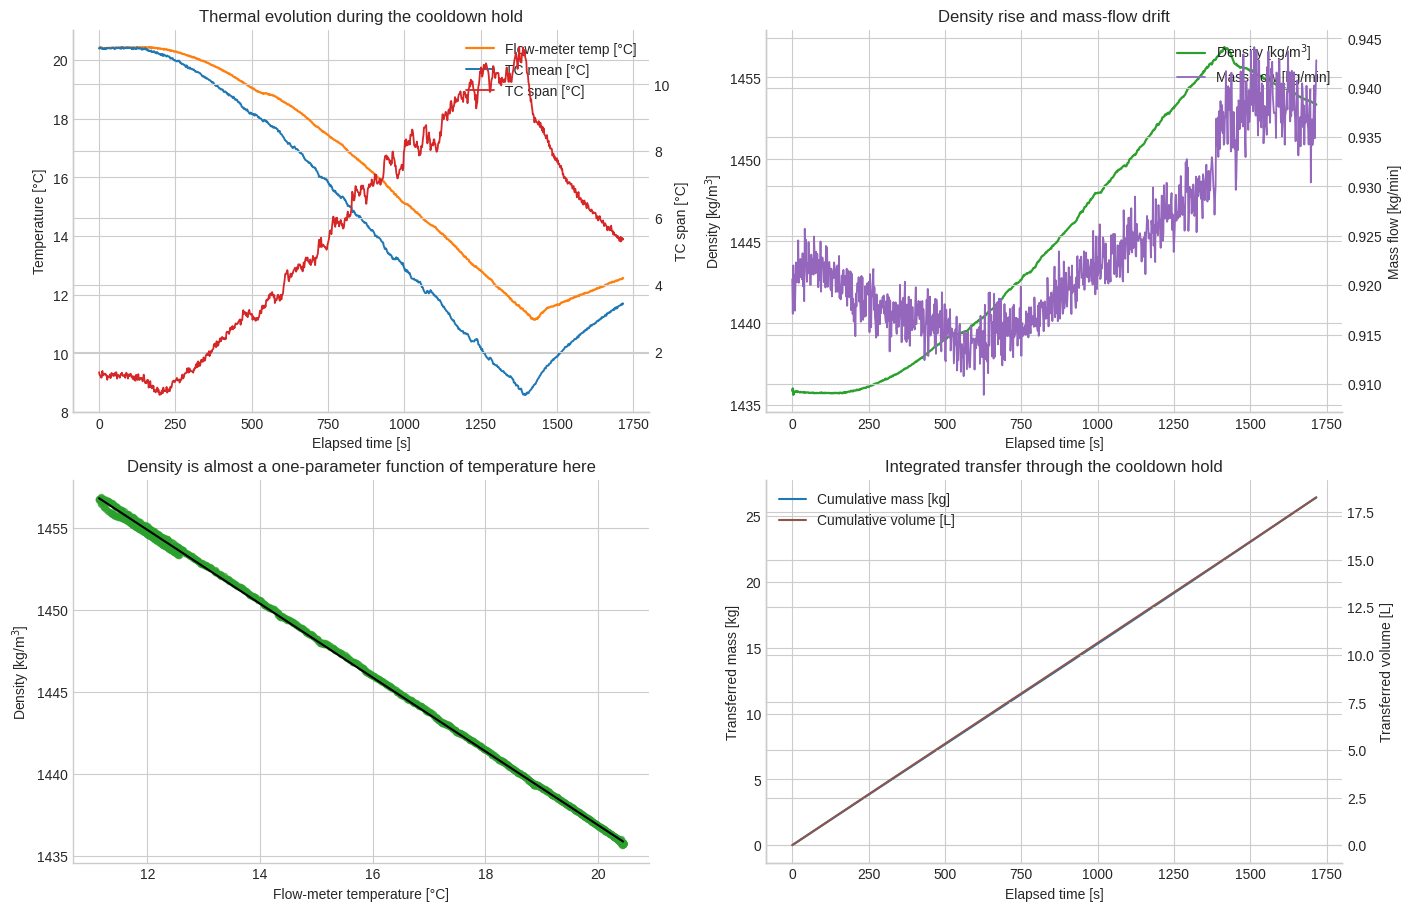

In [9]:
cooldown_row = segment_summary.loc[cooldown_segment_id]
cooldown = segment_slice(df, cooldown_row)
cool_liquid = cooldown[cooldown['liquid_like_density'] & (cooldown['pump_cmd_pct'] > 0.0)].copy()
cool_liquid['elapsed_s'] = cool_liquid['time_s'] - cool_liquid['time_s'].iloc[0]
cool_liquid['dt_s'] = cool_liquid['time_s'].diff().fillna(0.0).clip(lower=0.0)
cool_liquid['mass_increment_kg'] = cool_liquid['mass_flow_kgmin_si'] * cool_liquid['dt_s'] / 60.0
cool_liquid['volume_increment_l'] = cool_liquid['volume_flow_lmin_si'] * cool_liquid['dt_s'] / 60.0
cool_liquid['cum_mass_kg'] = cool_liquid['mass_increment_kg'].cumsum()
cool_liquid['cum_volume_l'] = cool_liquid['volume_increment_l'].cumsum()
if valid_temp_cols:
    cool_liquid['temp_mean_C'] = cool_liquid[valid_temp_cols].mean(axis=1)
    cool_liquid['temp_span_C'] = cool_liquid[valid_temp_cols].max(axis=1) - cool_liquid[valid_temp_cols].min(axis=1)
else:
    cool_liquid['temp_mean_C'] = np.nan
    cool_liquid['temp_span_C'] = np.nan

fit_density_temp = linregress(cool_liquid['temperature_c_si'], cool_liquid['density_kg_m3_si'])
fit_flow_temp = linregress(cool_liquid['temperature_c_si'], cool_liquid['mass_flow_kgmin_si'])
fit_temp_time = linregress(cool_liquid['elapsed_s'], cool_liquid['temperature_c_si'])
fit_density_time = linregress(cool_liquid['elapsed_s'], cool_liquid['density_kg_m3_si'])
fit_span_time = linregress(cool_liquid['elapsed_s'], cool_liquid['temp_span_C'])

cool_liquid['phase'] = pd.qcut(cool_liquid['elapsed_s'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
phase_summary = (
    cool_liquid.groupby('phase', observed=False)
    .agg(
        median_flow_temp_C=('temperature_c_si', 'median'),
        median_density_kg_m3=('density_kg_m3_si', 'median'),
        median_mass_flow_kgmin=('mass_flow_kgmin_si', 'median'),
        median_volume_flow_lmin=('volume_flow_lmin_si', 'median'),
        median_tc_mean_C=('temp_mean_C', 'median'),
        median_tc_span_C=('temp_span_C', 'median'),
    )
)

print(f'Segment {cooldown_segment_id} liquid-like duration: {cool_liquid["dt_s"].sum():.1f} s')
print(f'Cumulative transferred mass: {cool_liquid["cum_mass_kg"].iloc[-1]:.3f} kg')
print(f'Cumulative transferred volume: {cool_liquid["cum_volume_l"].iloc[-1]:.3f} L')
print(f'Density vs flow-meter temperature slope: {fit_density_temp.slope:.3f} kg/m^3 per C, r^2 = {fit_density_temp.rvalue**2:.4f}')
print(f'Mass flow vs flow-meter temperature slope: {fit_flow_temp.slope:.4f} kg/min per C, r^2 = {fit_flow_temp.rvalue**2:.4f}')
print(f'Flow-meter temperature vs elapsed time slope: {fit_temp_time.slope:.5f} C/s, r^2 = {fit_temp_time.rvalue**2:.4f}')
print(f'Density vs elapsed time slope: {fit_density_time.slope:.5f} kg/m^3/s, r^2 = {fit_density_time.rvalue**2:.4f}')
print(f'Thermocouple span vs elapsed time slope: {fit_span_time.slope:.5f} C/s, r^2 = {fit_span_time.rvalue**2:.4f}')
display(phase_summary.round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

axes[0, 0].plot(cool_liquid['elapsed_s'], cool_liquid['temperature_c_si'], lw=1.6, color='tab:orange', label='Flow-meter temp [°C]')
axes[0, 0].plot(cool_liquid['elapsed_s'], cool_liquid['temp_mean_C'], lw=1.4, color='tab:blue', label='TC mean [°C]')
ax_span = axes[0, 0].twinx()
ax_span.plot(cool_liquid['elapsed_s'], cool_liquid['temp_span_C'], lw=1.3, color='tab:red', label='TC span [°C]')
axes[0, 0].set_xlabel('Elapsed time [s]')
axes[0, 0].set_ylabel('Temperature [°C]')
ax_span.set_ylabel('TC span [°C]')
axes[0, 0].set_title('Thermal evolution during the cooldown hold')
lines = axes[0, 0].get_lines() + ax_span.get_lines()
axes[0, 0].legend(lines, [line.get_label() for line in lines], loc='upper right')

axes[0, 1].plot(cool_liquid['elapsed_s'], cool_liquid['density_kg_m3_si'], lw=1.6, color='tab:green', label='Density [kg/m$^3$]')
ax_mass = axes[0, 1].twinx()
ax_mass.plot(cool_liquid['elapsed_s'], cool_liquid['mass_flow_kgmin_si'], lw=1.3, color='tab:purple', label='Mass flow [kg/min]')
axes[0, 1].set_xlabel('Elapsed time [s]')
axes[0, 1].set_ylabel('Density [kg/m$^3$]')
ax_mass.set_ylabel('Mass flow [kg/min]')
axes[0, 1].set_title('Density rise and mass-flow drift')
lines = axes[0, 1].get_lines() + ax_mass.get_lines()
axes[0, 1].legend(lines, [line.get_label() for line in lines], loc='upper right')

axes[1, 0].scatter(cool_liquid['temperature_c_si'], cool_liquid['density_kg_m3_si'], s=20, alpha=0.6, color='tab:green')
fit_x = np.linspace(cool_liquid['temperature_c_si'].min(), cool_liquid['temperature_c_si'].max(), 200)
axes[1, 0].plot(fit_x, fit_density_temp.intercept + fit_density_temp.slope * fit_x, color='black', lw=1.5)
axes[1, 0].set_xlabel('Flow-meter temperature [°C]')
axes[1, 0].set_ylabel('Density [kg/m$^3$]')
axes[1, 0].set_title('Density is almost a one-parameter function of temperature here')

axes[1, 1].plot(cool_liquid['elapsed_s'], cool_liquid['cum_mass_kg'], lw=1.5, color='tab:blue', label='Cumulative mass [kg]')
ax_volume = axes[1, 1].twinx()
ax_volume.plot(cool_liquid['elapsed_s'], cool_liquid['cum_volume_l'], lw=1.5, color='tab:brown', label='Cumulative volume [L]')
axes[1, 1].set_xlabel('Elapsed time [s]')
axes[1, 1].set_ylabel('Transferred mass [kg]')
ax_volume.set_ylabel('Transferred volume [L]')
axes[1, 1].set_title('Integrated transfer through the cooldown hold')
lines = axes[1, 1].get_lines() + ax_volume.get_lines()
axes[1, 1].legend(lines, [line.get_label() for line in lines], loc='upper left')

plt.show()


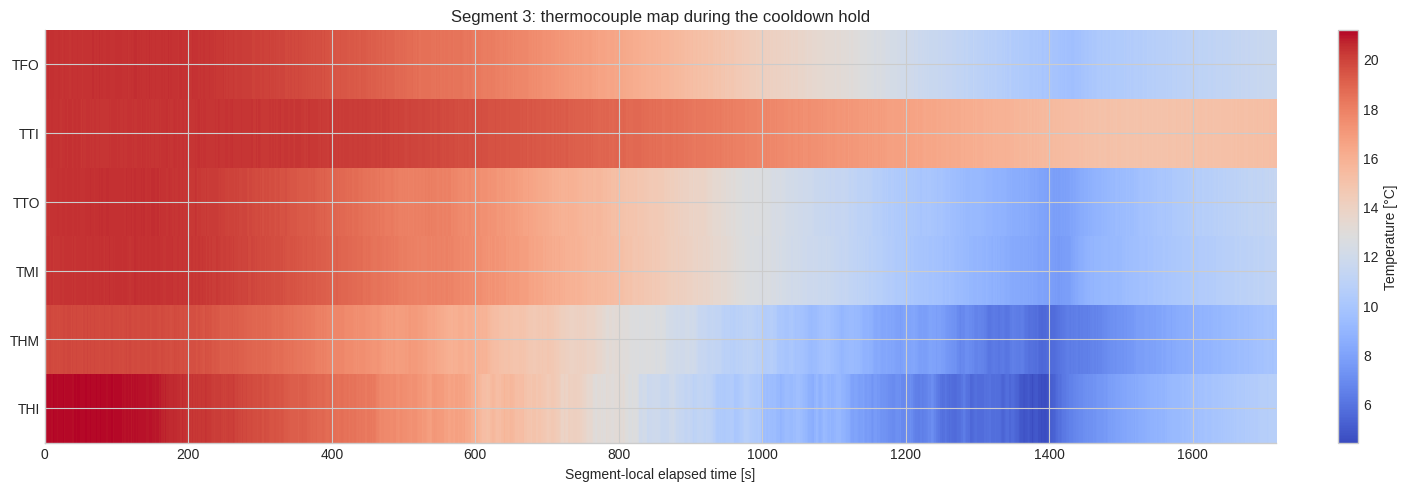

In [10]:
if valid_temp_cols:
    fig, ax = plt.subplots(figsize=(14, 4.8), constrained_layout=True)
    temp_map = cool_liquid[valid_temp_cols].to_numpy().T
    image = ax.imshow(
        temp_map,
        aspect='auto',
        interpolation='nearest',
        cmap='coolwarm',
        extent=[
            cool_liquid['elapsed_s'].min(),
            cool_liquid['elapsed_s'].max(),
            len(valid_temp_cols) - 0.5,
            -0.5,
        ],
    )
    ax.set_yticks(range(len(valid_temp_cols)), labels=[orca.tc_display_name(c) for c in valid_temp_cols])
    ax.set_xlabel('Segment-local elapsed time [s]')
    ax.set_title(f'Segment {cooldown_segment_id}: thermocouple map during the cooldown hold')
    colorbar = plt.colorbar(image, ax=ax)
    colorbar.set_label('Temperature [°C]')
    plt.show()


## Pump Telemetry vs Temperature

For the long 10% cooldown hold, the pump electrical telemetry is mostly stable while the fluid state changes underneath it. This section checks which logged channels actually move with the flow-meter temperature.

The practical question is whether we can infer viscosity directly from pump-side changes. If frequency, power, current, or differential pressure changed strongly with temperature, that would support a pump-derived viscosity estimate. In this run they stay mostly flat, so the notebook now keeps only a data-only viscosity proxy anchored to a reference operating point.


,signal,slope_per_C,r,r2,segment_min,segment_median,segment_max,end_minus_start
10,density_kg_m3_si,-2.2510,-0.9998,0.9996,1435.6366,1444.8157,1456.8515,17.4545
8,mass_flow_kgmin_si,-0.0021,-0.8194,0.6714,0.9089,0.9211,0.9441,0.0222
0,pump_freq_hz,-0.0020,-0.4348,0.1891,6.6900,6.7200,6.7800,0.0000
6,pump_pressure_tank_bar_abs,0.0059,0.3925,0.1541,1.0130,1.1010,1.2470,-0.0480
9,volume_flow_lmin_si,-0.0004,-0.3862,0.1492,0.6310,0.6381,0.6489,0.0075
4,pump_pressure_before_bar_abs,0.0051,0.3431,0.1177,1.1400,1.2960,1.4320,0.0390
5,pump_pressure_after_bar_abs,0.0046,0.2852,0.0814,1.1510,1.3080,1.4650,0.0390
1,pump_input_power_w,-0.0411,-0.2524,0.0637,50.0000,51.0000,53.0000,0.0000
2,pump_output_current_a,-0.0002,-0.0744,0.0055,2.3400,2.3600,2.3800,0.0000
7,delta_p_bar_recomputed,-0.0006,-0.0274,0.0008,-0.2230,0.0120,0.2280,0.0000


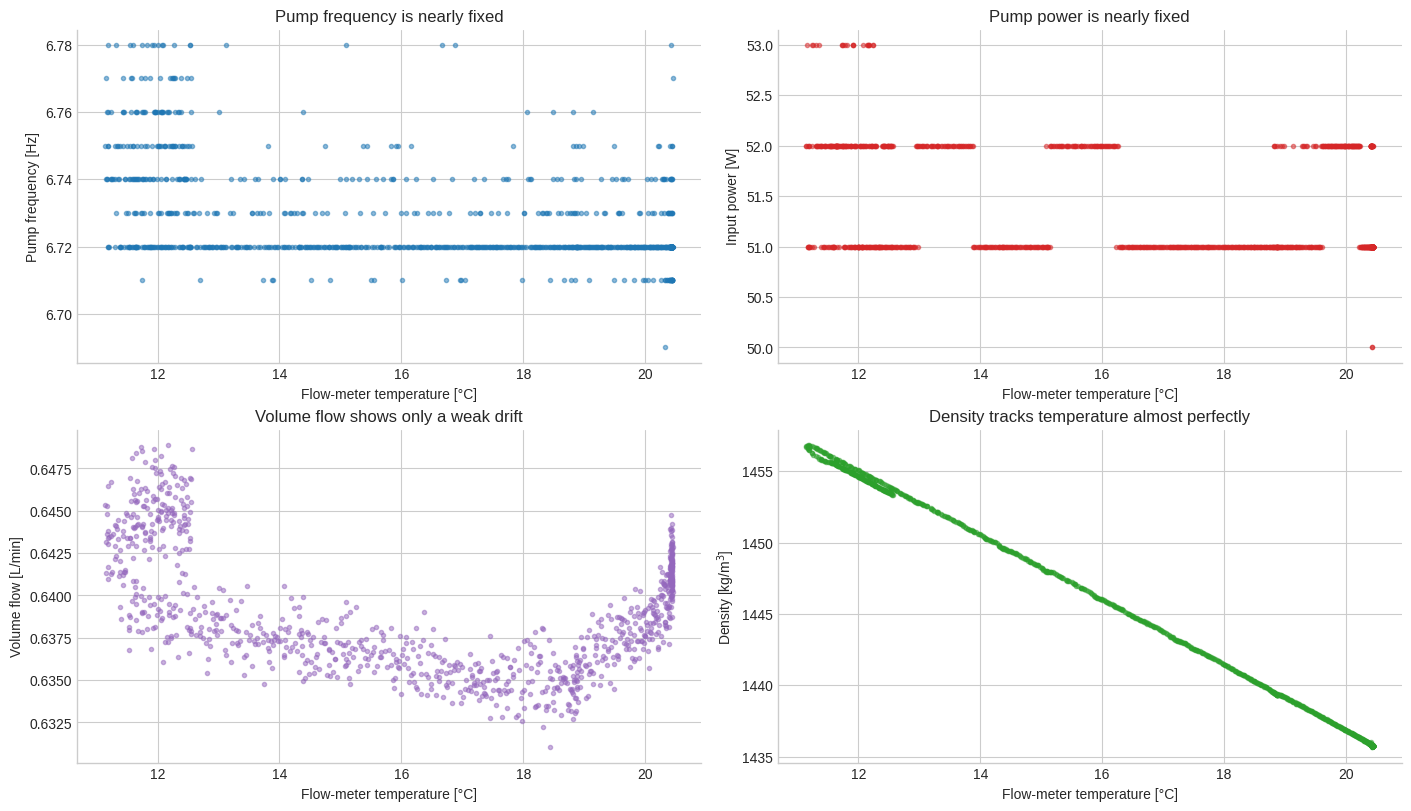

In [11]:
pump_temp_rows = []
pump_temp_signals = [
    'pump_freq_hz',
    'pump_input_power_w',
    'pump_output_current_a',
    'pump_output_voltage_v',
    'pump_pressure_before_bar_abs',
    'pump_pressure_after_bar_abs',
    'pump_pressure_tank_bar_abs',
    'delta_p_bar_recomputed',
    'mass_flow_kgmin_si',
    'volume_flow_lmin_si',
    'density_kg_m3_si',
]
for signal in pump_temp_signals:
    fit = linregress(cool_liquid['temperature_c_si'], cool_liquid[signal])
    pump_temp_rows.append(
        {
            'signal': signal,
            'slope_per_C': fit.slope,
            'r': fit.rvalue,
            'r2': fit.rvalue ** 2,
            'segment_min': cool_liquid[signal].min(),
            'segment_median': cool_liquid[signal].median(),
            'segment_max': cool_liquid[signal].max(),
            'end_minus_start': cool_liquid[signal].iloc[-1] - cool_liquid[signal].iloc[0],
        }
    )

pump_temp_summary = pd.DataFrame(pump_temp_rows).sort_values('r2', ascending=False)
display(pump_temp_summary.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
axes[0, 0].plot(cool_liquid['temperature_c_si'], cool_liquid['pump_freq_hz'], '.', alpha=0.5)
axes[0, 0].set_xlabel('Flow-meter temperature [°C]')
axes[0, 0].set_ylabel('Pump frequency [Hz]')
axes[0, 0].set_title('Pump frequency is nearly fixed')

axes[0, 1].plot(cool_liquid['temperature_c_si'], cool_liquid['pump_input_power_w'], '.', alpha=0.5, color='tab:red')
axes[0, 1].set_xlabel('Flow-meter temperature [°C]')
axes[0, 1].set_ylabel('Input power [W]')
axes[0, 1].set_title('Pump power is nearly fixed')

axes[1, 0].plot(cool_liquid['temperature_c_si'], cool_liquid['volume_flow_lmin_si'], '.', alpha=0.5, color='tab:purple')
axes[1, 0].set_xlabel('Flow-meter temperature [°C]')
axes[1, 0].set_ylabel('Volume flow [L/min]')
axes[1, 0].set_title('Volume flow shows only a weak drift')

axes[1, 1].plot(cool_liquid['temperature_c_si'], cool_liquid['density_kg_m3_si'], '.', alpha=0.5, color='tab:green')
axes[1, 1].set_xlabel('Flow-meter temperature [°C]')
axes[1, 1].set_ylabel('Density [kg/m$^3$]')
axes[1, 1].set_title('Density tracks temperature almost perfectly')

plt.show()


## Data-Only Viscosity Proxy

The previous internal temperature-to-viscosity surrogate has been removed from the repo. For this notebook, the remaining viscosity view stays deliberately simple and uses:

1. the `3M` room-temperature `N7200` reference, and
2. measured hydraulic evolution in the log after that.

The kinematic room-temperature anchor is taken from the `3M` freezing-data table: `0.41 cSt` at `25°C`. To convert that into a dynamic-viscosity room-temperature anchor, the notebook extrapolates the measured Segment 3 density trend up to `25°C` and uses:

`mu_25 = nu_25 * rho_25 / 1000`

The flow anchors at `25°C` are extrapolated in the same way from the measured Segment 3 flow trends. That keeps the proxy tied to the `3M` room-temperature point while still using only this run's measured evolution to carry the estimate into the colder tested range.


,value
warm_reference_segment_id,2.0000
3m_kinematic_viscosity_25C_cSt,0.4100
data_fit_density_25C_kg_m3,1425.6115
implied_dynamic_viscosity_25C_cP,0.5845
data_fit_volume_flow_25C_Lmin,0.6352
data_fit_mass_flow_25C_kgmin,0.9055


,cold_end,warm_end,median
dynamic_viscosity_proxy,0.5722,0.5884,0.5819
kinematic_viscosity_proxy,0.3932,0.4085,0.4030


,median_temp_C,median_density_kg_m3,median_dynamic_proxy_cP,median_kinematic_proxy_cSt,median_volume_flow_Lmin,median_mass_flow_kgmin
phase,,,,,,
Q1,20.376,1435.9317,0.5800,0.4039,0.6401,0.9192
Q2,18.323,1440.7045,0.5845,0.4055,0.6352,0.9156
Q3,14.484,1449.3820,0.5827,0.4021,0.6372,0.9234
Q4,11.916,1454.9319,0.5766,0.3963,0.6439,0.9369


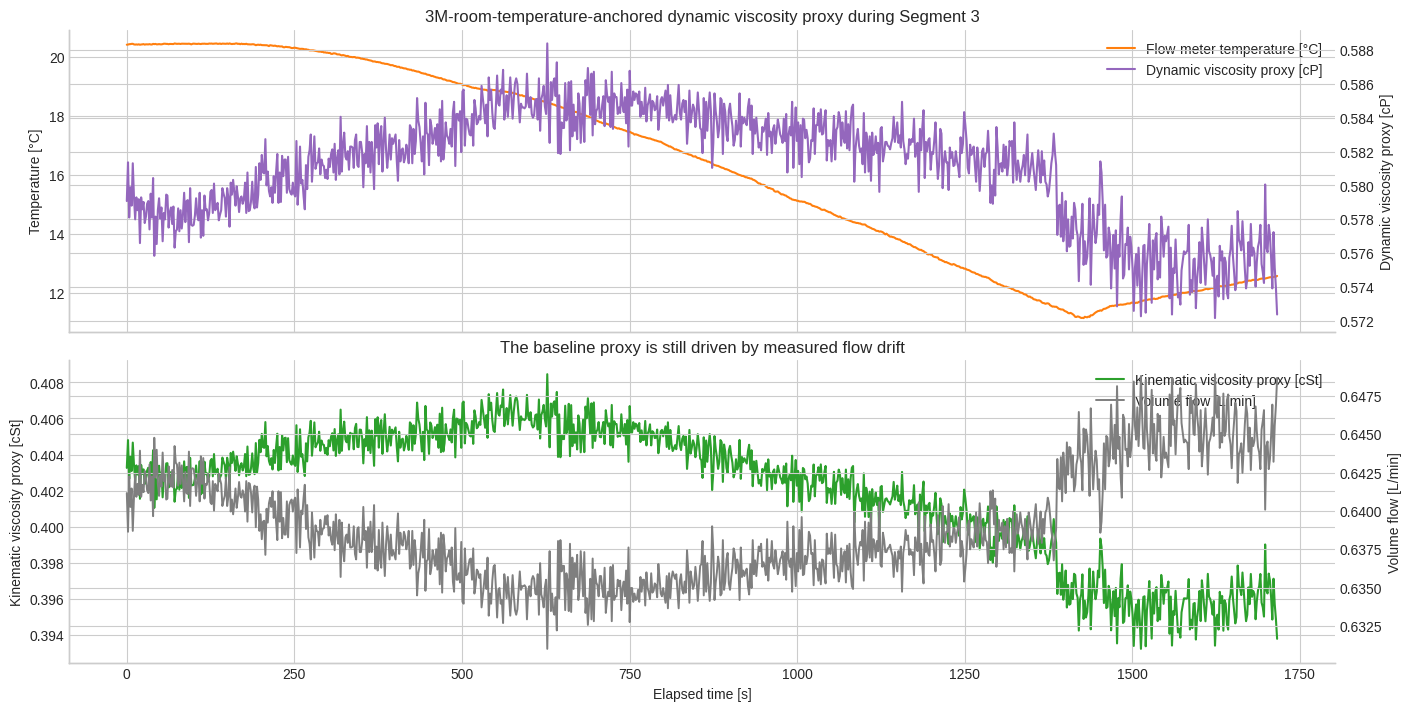

In [12]:
reference_3m_n7200_room = pd.DataFrame(
    {
        'temperature_c': [25.0, 0.0, -10.0, -20.0, -30.0, -40.0, -50.0, -60.0, -70.0, -100.0, -120.0],
        'kinematic_viscosity_cSt': [0.41, 0.67, 0.78, 0.93, 1.14, 1.42, 1.84, 2.48, 3.72, 12.47, 64.47],
    }
).sort_values('temperature_c')

NU_REF_25C_3M_CST = float(
    reference_3m_n7200_room.loc[
        reference_3m_n7200_room['temperature_c'].eq(25.0),
        'kinematic_viscosity_cSt',
    ].iloc[0]
)
fit_volume_temp = linregress(cool_liquid['temperature_c_si'], cool_liquid['volume_flow_lmin_si'])
fit_mass_temp = linregress(cool_liquid['temperature_c_si'], cool_liquid['mass_flow_kgmin_si'])

WARM_REF_SEGMENT_ID = min(repeatability_segment_ids)
rho_25_fit_kg_m3 = fit_density_temp.intercept + fit_density_temp.slope * 25.0
q_25_fit_lmin = fit_volume_temp.intercept + fit_volume_temp.slope * 25.0
mdot_25_fit_kgmin = fit_mass_temp.intercept + fit_mass_temp.slope * 25.0
MU_REF_ROOM_CP = NU_REF_25C_3M_CST * rho_25_fit_kg_m3 / 1000.0

cool_liquid['viscosity_proxy_cP'] = MU_REF_ROOM_CP * q_25_fit_lmin / cool_liquid['volume_flow_lmin_si']
cool_liquid['kinematic_proxy_cSt'] = NU_REF_25C_3M_CST * mdot_25_fit_kgmin / cool_liquid['mass_flow_kgmin_si']
cool_liquid['viscosity_proxy_rel_start'] = cool_liquid['viscosity_proxy_cP'] / cool_liquid['viscosity_proxy_cP'].iloc[0]
cool_liquid['kinematic_proxy_rel_start'] = cool_liquid['kinematic_proxy_cSt'] / cool_liquid['kinematic_proxy_cSt'].iloc[0]

reference_summary = pd.DataFrame(
    {
        'value': [
            WARM_REF_SEGMENT_ID,
            NU_REF_25C_3M_CST,
            rho_25_fit_kg_m3,
            MU_REF_ROOM_CP,
            q_25_fit_lmin,
            mdot_25_fit_kgmin,
        ]
    },
    index=[
        'warm_reference_segment_id',
        '3m_kinematic_viscosity_25C_cSt',
        'data_fit_density_25C_kg_m3',
        'implied_dynamic_viscosity_25C_cP',
        'data_fit_volume_flow_25C_Lmin',
        'data_fit_mass_flow_25C_kgmin',
    ],
)
display(reference_summary.round(4))

proxy_summary = pd.DataFrame(
    {
        'cold_end': [
            cool_liquid['viscosity_proxy_cP'].min(),
            cool_liquid['kinematic_proxy_cSt'].min(),
        ],
        'warm_end': [
            cool_liquid['viscosity_proxy_cP'].max(),
            cool_liquid['kinematic_proxy_cSt'].max(),
        ],
        'median': [
            cool_liquid['viscosity_proxy_cP'].median(),
            cool_liquid['kinematic_proxy_cSt'].median(),
        ],
    },
    index=['dynamic_viscosity_proxy', 'kinematic_viscosity_proxy'],
)
display(proxy_summary.round(4))

proxy_phase_summary = (
    cool_liquid.groupby('phase', observed=False)
    .agg(
        median_temp_C=('temperature_c_si', 'median'),
        median_density_kg_m3=('density_kg_m3_si', 'median'),
        median_dynamic_proxy_cP=('viscosity_proxy_cP', 'median'),
        median_kinematic_proxy_cSt=('kinematic_proxy_cSt', 'median'),
        median_volume_flow_Lmin=('volume_flow_lmin_si', 'median'),
        median_mass_flow_kgmin=('mass_flow_kgmin_si', 'median'),
    )
)
display(proxy_phase_summary.round(4))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)
axes[0].plot(cool_liquid['elapsed_s'], cool_liquid['temperature_c_si'], lw=1.5, color='tab:orange', label='Flow-meter temperature [°C]')
ax_mu = axes[0].twinx()
ax_mu.plot(cool_liquid['elapsed_s'], cool_liquid['viscosity_proxy_cP'], lw=1.5, color='tab:purple', label='Dynamic viscosity proxy [cP]')
axes[0].set_ylabel('Temperature [°C]')
ax_mu.set_ylabel('Dynamic viscosity proxy [cP]')
axes[0].set_title('3M-room-temperature-anchored dynamic viscosity proxy during Segment 3')
lines = axes[0].get_lines() + ax_mu.get_lines()
axes[0].legend(lines, [line.get_label() for line in lines], loc='upper right')

axes[1].plot(cool_liquid['elapsed_s'], cool_liquid['kinematic_proxy_cSt'], lw=1.5, color='tab:green', label='Kinematic viscosity proxy [cSt]')
ax_q = axes[1].twinx()
ax_q.plot(cool_liquid['elapsed_s'], cool_liquid['volume_flow_lmin_si'], lw=1.4, color='tab:gray', label='Volume flow [L/min]')
axes[1].set_xlabel('Elapsed time [s]')
axes[1].set_ylabel('Kinematic viscosity proxy [cSt]')
ax_q.set_ylabel('Volume flow [L/min]')
axes[1].set_title('The baseline proxy is still driven by measured flow drift')
lines = axes[1].get_lines() + ax_q.get_lines()
axes[1].legend(lines, [line.get_label() for line in lines], loc='upper right')

plt.show()


## 3M-anchored Extrapolations vs the Published N7200 Curve

The last slide of [HFE Freezing Data.pdf](../../docs/HFE%20Freezing%20Data.pdf) gives a pure `N7200` **kinematic viscosity** table from `3M`, including the room-temperature point `0.41 cSt` at `25°C`.

The base anchor for every model below is that `3M` room-temperature point. The log only spans about `11°C` to `20°C`, so the missing `25°C` flow and density anchor values are estimated by extending the measured Segment 3 trends slightly upward to `25°C`.

The comparison now includes three model families:

1. **Inverse-flow models**: the original laminar/head-limited idea, where higher viscosity would reduce flow.
2. **Reduced-slip models**: a positive-displacement style idea, where higher viscosity can reduce slip and slightly increase delivered flow.
3. **Hybrid power-law fits**: empirical models that keep the same measured variable shape but let the exponent be chosen to best match the `3M` curve over the tested window.

The hybrid power-law curves are not pure data-only extrapolations anymore, because they use the `3M` reference to tune the exponent. They are included as a diagnostic: if they fit much better, that tells us which hydraulic direction is at least more compatible with the published fluid-property trend.


,value
3m_reference_25C_cSt,0.4100
data_fit_density_at_25C_kg_m3,1425.6115
implied_dynamic_viscosity_at_25C_cP,0.5845
data_fit_volume_flow_at_25C_Lmin,0.6352
data_fit_mass_flow_at_25C_kgmin,0.9055
tested_temp_min_C,11.1450
tested_temp_max_C,20.4480


,cold_end_cSt,warm_end_cSt,cold_over_warm,median_cSt,median_over_3m,rmse_vs_3m_cSt
method,,,,,,
Mass power fit (alpha=9.98),0.5581,0.4542,1.2288,0.4958,0.9951,0.0027
Density power fit (beta=14.26),0.5582,0.4541,1.2293,0.4957,0.9949,0.0028
Reduced-slip mass fit,0.4229,0.4142,1.0208,0.4179,0.8387,0.0891
Reduced-slip density fit,0.4190,0.4129,1.0146,0.4155,0.8339,0.0917
3M 25°C anchor only,0.4100,0.4100,1.0000,0.4100,0.8229,0.0978
Inverse volume + density fit,0.3976,0.4058,0.9796,0.4023,0.8074,0.1063
Inverse mass-flow fit,0.3975,0.4058,0.9796,0.4023,0.8074,0.1063


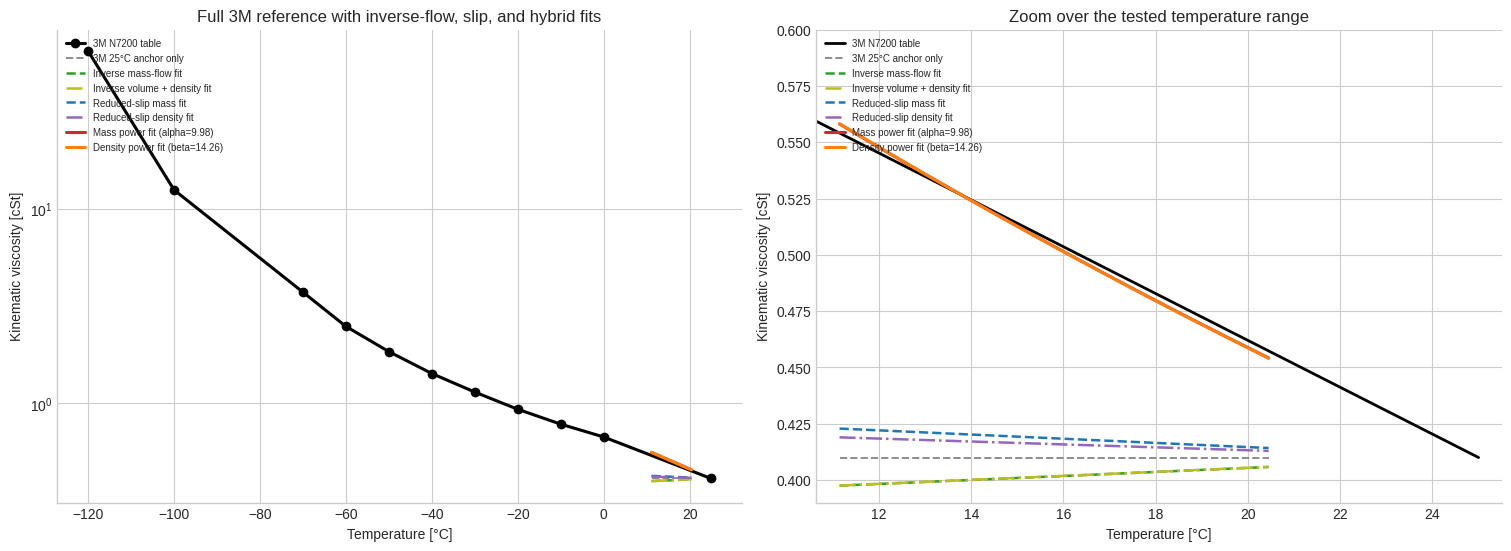

In [13]:
from scipy.optimize import minimize_scalar

reference_3m_n7200 = pd.DataFrame(
    {
        'temperature_c': [25.0, 0.0, -10.0, -20.0, -30.0, -40.0, -50.0, -60.0, -70.0, -100.0, -120.0],
        'kinematic_viscosity_cSt': [0.41, 0.67, 0.78, 0.93, 1.14, 1.42, 1.84, 2.48, 3.72, 12.47, 64.47],
    }
).sort_values('temperature_c')

NU_REF_25C_3M_CST = float(
    reference_3m_n7200.loc[reference_3m_n7200['temperature_c'].eq(25.0), 'kinematic_viscosity_cSt'].iloc[0]
)
fit_volume_temp = linregress(cool_liquid['temperature_c_si'], cool_liquid['volume_flow_lmin_si'])
fit_mass_temp = linregress(cool_liquid['temperature_c_si'], cool_liquid['mass_flow_kgmin_si'])

rho_25_fit_kg_m3 = fit_density_temp.intercept + fit_density_temp.slope * 25.0
q_25_fit_lmin = fit_volume_temp.intercept + fit_volume_temp.slope * 25.0
mdot_25_fit_kgmin = fit_mass_temp.intercept + fit_mass_temp.slope * 25.0
mu_25_from_3m_cp = NU_REF_25C_3M_CST * rho_25_fit_kg_m3 / 1000.0

cool_liquid_sorted = cool_liquid.sort_values('temperature_c_si').copy()
cool_liquid_sorted['density_fit_kg_m3'] = (
    fit_density_temp.intercept + fit_density_temp.slope * cool_liquid_sorted['temperature_c_si']
)
cool_liquid_sorted['volume_flow_fit_lmin'] = (
    fit_volume_temp.intercept + fit_volume_temp.slope * cool_liquid_sorted['temperature_c_si']
)
cool_liquid_sorted['mass_flow_fit_kgmin'] = (
    fit_mass_temp.intercept + fit_mass_temp.slope * cool_liquid_sorted['temperature_c_si']
)

reference_interp_cSt = np.interp(
    cool_liquid_sorted['temperature_c_si'],
    reference_3m_n7200['temperature_c'],
    reference_3m_n7200['kinematic_viscosity_cSt'],
)

mass_ratio_fit = cool_liquid_sorted['mass_flow_fit_kgmin'].to_numpy() / mdot_25_fit_kgmin
density_ratio_fit = cool_liquid_sorted['density_fit_kg_m3'].to_numpy() / rho_25_fit_kg_m3

def fit_power_curve(base_ratio: np.ndarray, anchor_cSt: float, target_cSt: np.ndarray):
    def objective(alpha: float) -> float:
        values = anchor_cSt * np.power(base_ratio, alpha)
        return float(np.sqrt(np.mean((values - target_cSt) ** 2)))

    result = minimize_scalar(objective, bounds=(-15.0, 15.0), method='bounded')
    alpha = float(result.x)
    values = anchor_cSt * np.power(base_ratio, alpha)
    return alpha, values, float(result.fun)

mass_power_alpha, mass_power_curve, mass_power_rmse = fit_power_curve(
    mass_ratio_fit,
    NU_REF_25C_3M_CST,
    reference_interp_cSt,
)
density_power_beta, density_power_curve, density_power_rmse = fit_power_curve(
    density_ratio_fit,
    NU_REF_25C_3M_CST,
    reference_interp_cSt,
)

extrapolation_curves = {
    '3M 25°C anchor only': np.full(len(cool_liquid_sorted), NU_REF_25C_3M_CST),
    'Inverse mass-flow fit': (
        NU_REF_25C_3M_CST * mdot_25_fit_kgmin / cool_liquid_sorted['mass_flow_fit_kgmin'].to_numpy()
    ),
    'Inverse volume + density fit': (
        NU_REF_25C_3M_CST
        * (q_25_fit_lmin / cool_liquid_sorted['volume_flow_fit_lmin'].to_numpy())
        * (rho_25_fit_kg_m3 / cool_liquid_sorted['density_fit_kg_m3'].to_numpy())
    ),
    'Reduced-slip mass fit': (
        NU_REF_25C_3M_CST * cool_liquid_sorted['mass_flow_fit_kgmin'].to_numpy() / mdot_25_fit_kgmin
    ),
    'Reduced-slip density fit': (
        NU_REF_25C_3M_CST * cool_liquid_sorted['density_fit_kg_m3'].to_numpy() / rho_25_fit_kg_m3
    ),
    f'Mass power fit (alpha={mass_power_alpha:.2f})': mass_power_curve,
    f'Density power fit (beta={density_power_beta:.2f})': density_power_curve,
}

anchor_summary = pd.DataFrame(
    {
        'value': [
            NU_REF_25C_3M_CST,
            rho_25_fit_kg_m3,
            mu_25_from_3m_cp,
            q_25_fit_lmin,
            mdot_25_fit_kgmin,
            cool_liquid_sorted['temperature_c_si'].min(),
            cool_liquid_sorted['temperature_c_si'].max(),
        ]
    },
    index=[
        '3m_reference_25C_cSt',
        'data_fit_density_at_25C_kg_m3',
        'implied_dynamic_viscosity_at_25C_cP',
        'data_fit_volume_flow_at_25C_Lmin',
        'data_fit_mass_flow_at_25C_kgmin',
        'tested_temp_min_C',
        'tested_temp_max_C',
    ],
)
display(anchor_summary.round(4))

method_rows = []
for label, values in extrapolation_curves.items():
    method_rows.append(
        {
            'method': label,
            'cold_end_cSt': values[0],
            'warm_end_cSt': values[-1],
            'cold_over_warm': values[0] / values[-1],
            'median_cSt': np.median(values),
            'median_over_3m': np.median(values / reference_interp_cSt),
            'rmse_vs_3m_cSt': np.sqrt(np.mean((values - reference_interp_cSt) ** 2)),
        }
    )
method_summary = pd.DataFrame(method_rows).set_index('method').sort_values('rmse_vs_3m_cSt')
display(method_summary.round(4))

curve_styles = {
    '3M 25°C anchor only': dict(color='0.55', ls='--', lw=1.4),
    'Inverse mass-flow fit': dict(color='tab:green', ls='--', lw=1.8),
    'Inverse volume + density fit': dict(color='tab:olive', ls='-.', lw=1.8),
    'Reduced-slip mass fit': dict(color='tab:blue', ls='--', lw=1.8),
    'Reduced-slip density fit': dict(color='tab:purple', ls='-.', lw=1.8),
    f'Mass power fit (alpha={mass_power_alpha:.2f})': dict(color='tab:red', ls='-', lw=2.2),
    f'Density power fit (beta={density_power_beta:.2f})': dict(color='tab:orange', ls='-', lw=2.2),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), constrained_layout=True)

axes[0].plot(
    reference_3m_n7200['temperature_c'],
    reference_3m_n7200['kinematic_viscosity_cSt'],
    color='black',
    marker='o',
    lw=2.2,
    label='3M N7200 table',
)
for label, values in extrapolation_curves.items():
    axes[0].plot(cool_liquid_sorted['temperature_c_si'], values, label=label, **curve_styles[label])
axes[0].set_yscale('log')
axes[0].set_xlabel('Temperature [°C]')
axes[0].set_ylabel('Kinematic viscosity [cSt]')
axes[0].set_title('Full 3M reference with inverse-flow, slip, and hybrid fits')
axes[0].legend(loc='upper left', fontsize=7)

axes[1].plot(
    reference_3m_n7200['temperature_c'],
    reference_3m_n7200['kinematic_viscosity_cSt'],
    color='black',
    lw=2.0,
    label='3M N7200 table',
)
for label, values in extrapolation_curves.items():
    axes[1].plot(cool_liquid_sorted['temperature_c_si'], values, label=label, **curve_styles[label])
axes[1].set_xlim(cool_liquid_sorted['temperature_c_si'].min() - 0.5, 25.5)
axes[1].set_ylim(0.39, 0.60)
axes[1].set_xlabel('Temperature [°C]')
axes[1].set_ylabel('Kinematic viscosity [cSt]')
axes[1].set_title('Zoom over the tested temperature range')
axes[1].legend(loc='upper left', fontsize=7)

plt.show()


## Reading The Plots

For this log, the phase split can be read as follows:

- **Segment 1** is the cleanest pump-characterization window. The settled step medians are monotonic and close to linear against pump frequency, especially for both mass flow and volume flow.
- **Segment 2** is a good warm baseline for 10% operation. Its flow, density, and temperature traces are all very stable after the first couple of minutes.
- **Segment 3** is the most informative thermal transient. At nearly fixed command and power, the fluid cools, density rises, and the thermocouple map shows the system becoming less uniform.
- **Segment 4** should not be used for quantitative liquid calibration. The density collapses far below the plausible liquid-HFE band, which is consistent with gas-rich or nearly emptied flow.
- **Viscosity extrapolations**: the notebook now compares inverse-flow models, reduced-slip models, and a pair of empirical power-law hybrids, all anchored to the `3M` room-temperature `0.41 cSt @ 25°C` point. The simple data-only models still sit below the published `3M` curve, but the hybrid power-law fits show how much extra nonlinearity would be needed to reproduce the `3M` trend over the tested `~11-20°C` window.

The most useful takeaway is that this file gives both a clean hydraulic sweep and a clean thermal transient. It is strong enough to build a simple data-only viscosity proxy, but not to identify viscosity uniquely without extra property information.
